In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv(r"C:\Users\rmstn\final_project\Geunsu\data\전처리완료_카드(가맹점).csv", encoding='utf-8')
df

,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,...,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt,mm_cnt_num
0,2023-01-01,41135,41135510,100470,Q13,음식,커피/음료,A,57,1,...,0,1,0,0,0,0,0,1,0,57
1,2023-01-01,41135,41135510,100470,R07,학문/교육,입시학원,A,84,1,...,0,1,0,0,0,0,0,0,1,84
2,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,A,1,1,...,1,0,1,0,0,1,0,0,0,1
3,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,E,32,1,...,0,0,1,0,0,1,0,0,0,32
4,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,신규,0,1,...,1,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2130066,2025-12-01,41135,41135670,99971,F02,생활서비스,미용서비스,A,6,1,...,0,1,0,1,0,0,0,0,0,6
2130067,2025-12-01,41135,41135670,99971,F06,생활서비스,세탁/가사서비스,A,199,1,...,0,0,0,0,0,0,0,0,1,199
2130068,2025-12-01,41135,41135670,99971,Q03,음식,닭/오리요리,A,166,1,...,0,0,0,0,0,0,0,0,1,166
2130069,2025-12-01,41135,41135670,99986,R03,학문/교육,기타교육,A,12,1,...,0,1,0,0,1,0,0,0,0,12


In [50]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 구명 매핑 (행정동 차트 가독성)
gu_map = {"41135": "분당구", "41133": "수정구", "41131": "중원구"}
df["구명"] = df["cty_rgn_no"].astype(str).map(gu_map)

# 행정동코드 → 행정동명 매핑 (seongnam_dong_master, 10자리 코드 앞 8자리로 매핑)
_dong_master = pd.read_csv(
    r"C:\Users\rmstn\final_project\Geunsu\data\seongnam_dong_master_202604282135.csv",
    encoding="cp949"
)
_dong_master["dong_code_8"] = _dong_master["dong_code"].astype(str).str[:8]
dong_map = _dong_master.set_index("dong_code_8")["dong_name"].to_dict()
df["행정동명"] = df["admi_cty_no"].astype(str).map(dong_map)

# 매출구간 E 제외 (분석용)
df_eda = df[df["sale"] != "E"].copy()
df_eda["ta_ym"] = pd.to_datetime(df_eda["ta_ym"])

# 원도심(수정구,중원구) / 분당구 분리
df_원도심 = df_eda[df_eda["cty_rgn_no"].astype(str).isin(["41133", "41131"])].copy()
df_분당구 = df_eda[df_eda["cty_rgn_no"].astype(str) == "41135"].copy()

print(f"전체: {len(df):,}행  →  E 제외 후: {len(df_eda):,}행")
print(f"  원도심(수정+중원): {len(df_원도심):,}행")
print(f"  분당구(신도심):    {len(df_분당구):,}행")
print()
print("매출구간 분포 (E 제외):")
print(df_eda["sale"].value_counts())

전체: 2,130,071행  →  E 제외 후: 1,742,211행
  원도심(수정+중원): 898,306행
  분당구(신도심):    843,905행

매출구간 분포 (E 제외):
sale
A     1069467
B      231895
C      214109
D      159267
신규      67473
Name: count, dtype: int64


## 1. 개폐업률 

| 지표 | 공식 |
|---|---|
| 개업률 (%) | Σ open_cnt / Σ mer_cnt × 100 |
| 폐업률 (%) | Σ close_cnt / Σ mer_cnt × 100 |

- 집계 단위별로 수량을 **합산한 뒤** 비율을 계산한다 (비율의 평균이 아님)
-  (30억 초과 또는 국세청 미등록) 제외

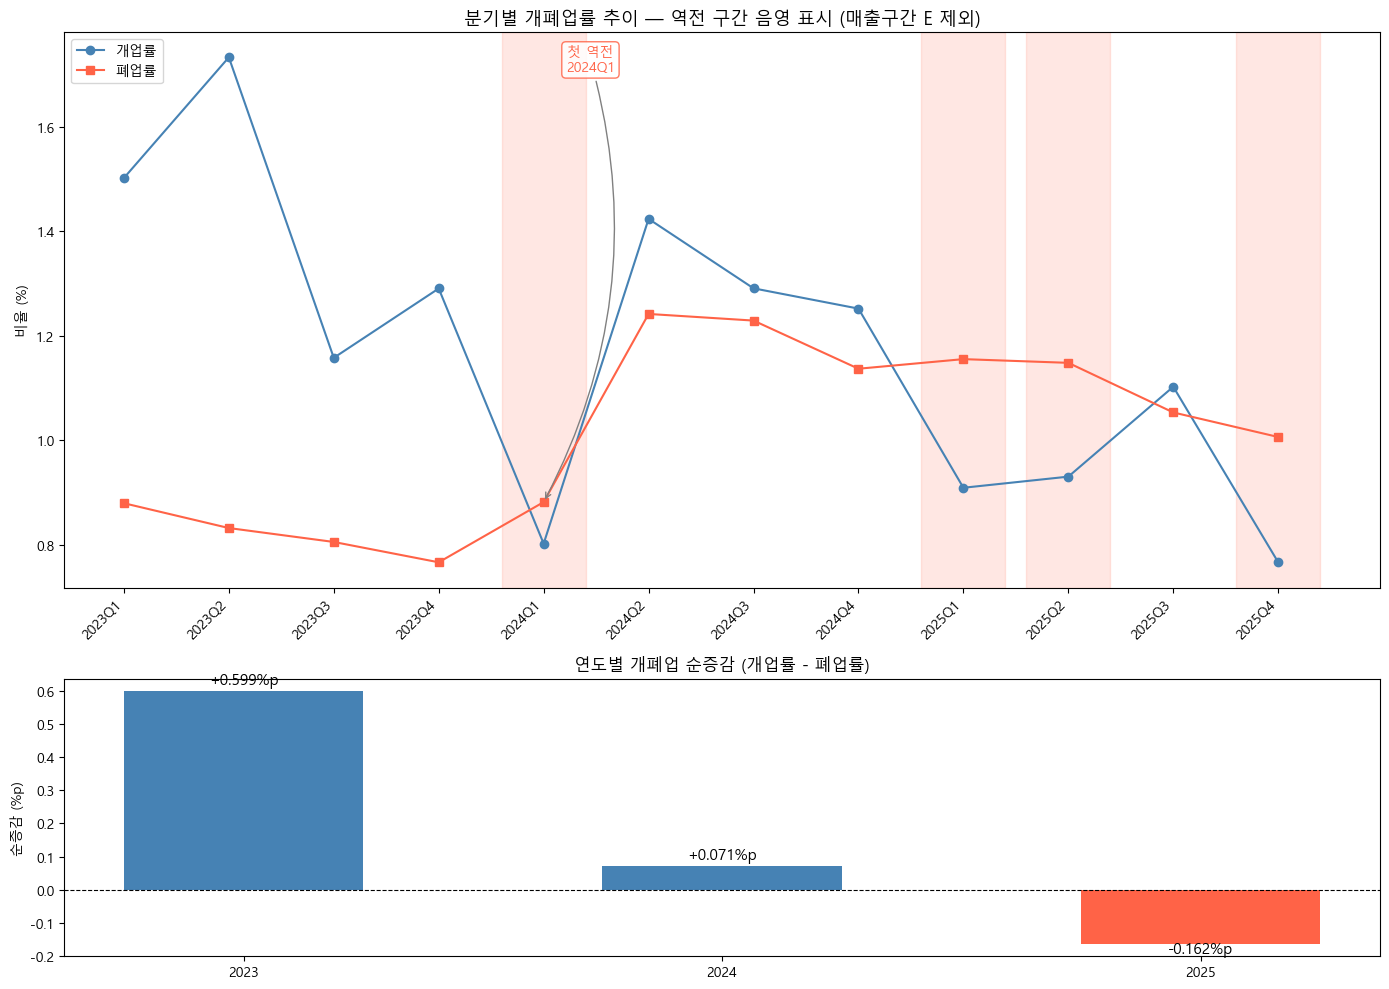

=== 연도별 개폐업률 요약 ===
         개업률    폐업률    순증감
ta_ym                     
2023   1.419  0.821  0.599
2024   1.195  1.124  0.071
2025   0.927  1.090 -0.162

역전 발생: 4개 분기 / 전체 12개 분기

=== 역전 구간 목록 (폐업률 > 개업률) ===
    분기      개업률      폐업률       순증감
2024Q1 0.802467 0.881960 -0.079494
2025Q1 0.909351 1.155424 -0.246073
2025Q2 0.930629 1.148329 -0.217700
2025Q4 0.766794 1.006440 -0.239646


In [51]:
# ── 구조적 전환점 분석 ───────────────────────────────────────────
# 개업률 < 폐업률 역전 구간을 음영으로 표시하고, 연도별 순증감을 병행 시각화

quarterly = (
    df_eda.assign(_q=df_eda["ta_ym"].dt.to_period("Q"))
    .groupby("_q")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
quarterly["개업률"] = quarterly["open_cnt"] / quarterly["mer_cnt"] * 100
quarterly["폐업률"] = quarterly["close_cnt"] / quarterly["mer_cnt"] * 100
quarterly["역전"]   = quarterly["폐업률"] > quarterly["개업률"]
quarterly["순증감"] = quarterly["개업률"] - quarterly["폐업률"]
quarterly["분기_str"] = quarterly["_q"].astype(str)

# 연도별 집계
yearly = (
    df_eda.groupby(df_eda["ta_ym"].dt.year)[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
)
yearly["개업률"] = yearly["open_cnt"] / yearly["mer_cnt"] * 100
yearly["폐업률"] = yearly["close_cnt"] / yearly["mer_cnt"] * 100
yearly["순증감"] = yearly["개업률"] - yearly["폐업률"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1.5]})

# 상단: 분기별 추이 + 역전 구간 음영 ──────────────────────────────────
ax = axes[0]
x_labels = quarterly["분기_str"].tolist()
x_idx    = list(range(len(x_labels)))

ax.plot(x_idx, quarterly["개업률"], marker="o", ms=6, label="개업률", color="steelblue")
ax.plot(x_idx, quarterly["폐업률"], marker="s", ms=6, label="폐업률", color="tomato")

for _, row in quarterly[quarterly["역전"]].iterrows():
    i = x_labels.index(row["분기_str"])
    ax.axvspan(i - 0.4, i + 0.4, alpha=0.15, color="tomato")

# 첫 역전 시점 주석
first_str = quarterly[quarterly["역전"]].iloc[0]["분기_str"]
first_i   = x_labels.index(first_str)
y_arrow   = quarterly.loc[quarterly["분기_str"] == first_str, "폐업률"].values[0]
ax.annotate(
    f"첫 역전\n{first_str}",
    xy=(first_i, y_arrow),
    xycoords="data",
    xytext=(0.4, 0.93),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="gray", connectionstyle="arc3,rad=-0.2"),
    fontsize=10, color="tomato", ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="tomato", alpha=0.85),
)

ax.set_title("분기별 개폐업률 추이 — 역전 구간 음영 표시 (매출구간 E 제외)", fontsize=13)
ax.set_ylabel("비율 (%)")
ax.set_xticks(x_idx)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.legend()

# 하단: 연도별 순증감 막대 ────────────────────────────────────────────
ax2 = axes[1]
bar_colors = ["steelblue" if v >= 0 else "tomato" for v in yearly["순증감"]]
bars = ax2.bar(yearly.index.astype(str), yearly["순증감"], color=bar_colors, width=0.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, v in zip(bars, yearly["순증감"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        v + (0.01 if v >= 0 else -0.04),
        f"{v:+.3f}%p",
        ha="center", va="bottom", fontsize=11,
    )
ax2.set_title("연도별 개폐업 순증감 (개업률 - 폐업률)", fontsize=12)
ax2.set_ylabel("순증감 (%p)")

plt.tight_layout()
plt.show()

# 수치 요약 출력
print("=== 연도별 개폐업률 요약 ===")
print(yearly[["개업률", "폐업률", "순증감"]].round(3).to_string())
print()
n_rev = quarterly["역전"].sum()
print(f"역전 발생: {n_rev}개 분기 / 전체 {len(quarterly)}개 분기")
print()
print("=== 역전 구간 목록 (폐업률 > 개업률) ===")
rev = quarterly[quarterly["역전"]][["분기_str", "개업률", "폐업률", "순증감"]].copy()
print(rev.rename(columns={"분기_str": "분기"}).to_string(index=False))

# 그래프 해석

- 2023년은 순증감이 약 0.6%p를 기록할만큼 신규 진입이 활발하고 퇴출 압력이 낮은 건강한 상태임
- 2024년 1분기에서 개업률이 0.8%로 급감하며 첫 역전이 발생함
- 2025년에 4개 분기중 3개가 폐업률이 개업률을 역전함. 이는 일시적 변동이 아닌 구조적 침체 국면 진입으로 판단됨

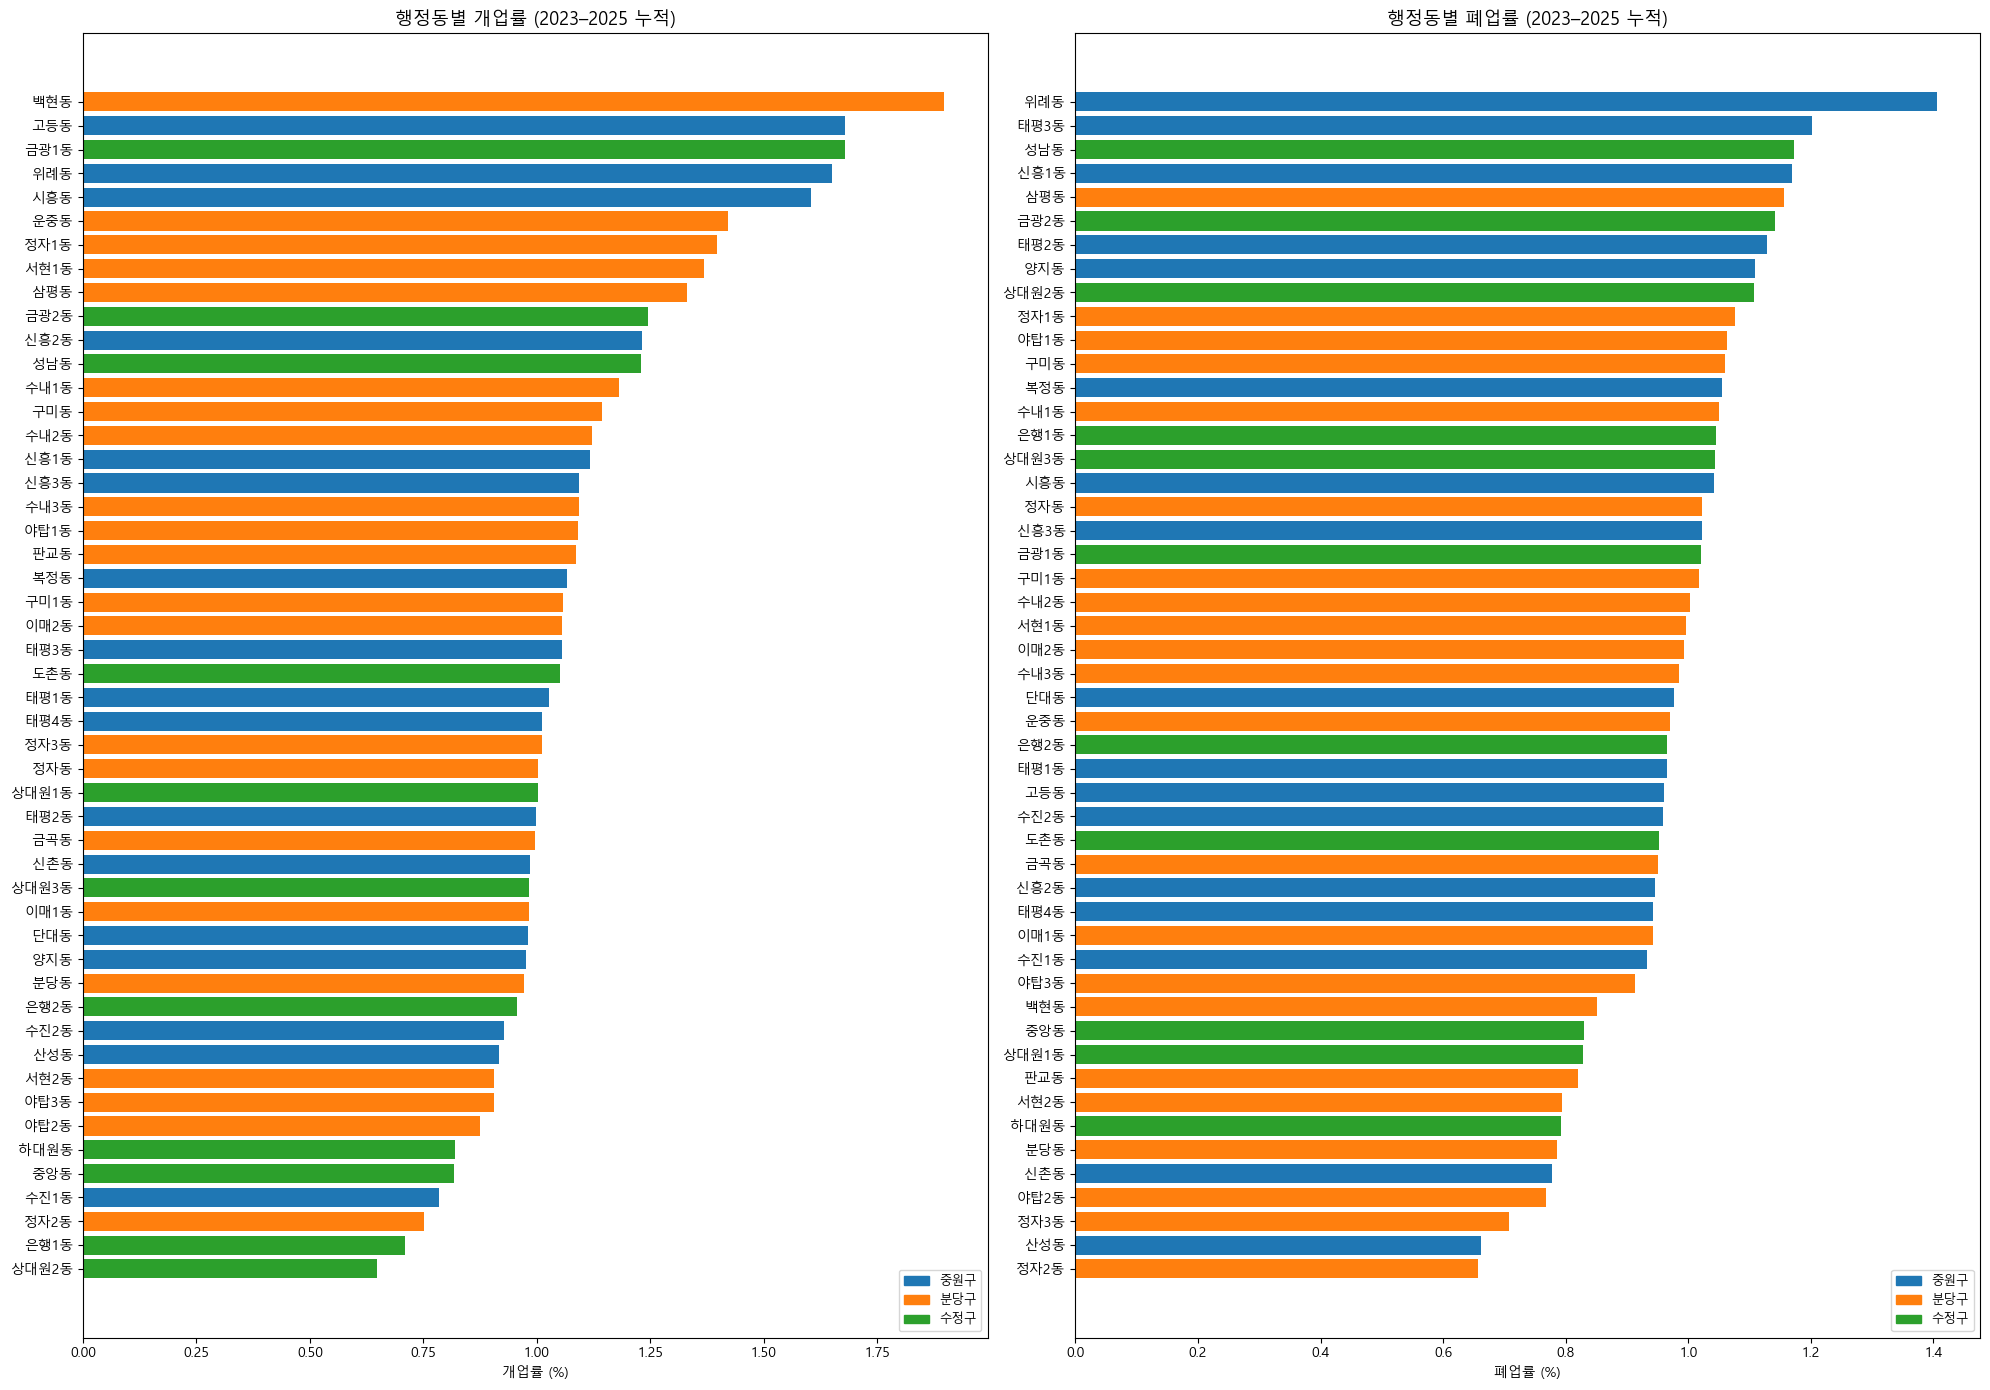

개업률 상위 5 행정동:
행정동명      개업률      폐업률
 백현동 1.898202 0.850960
 고등동 1.680176 0.959657
금광1동 1.679766 1.020188
 위례동 1.651286 1.405816
 시흥동 1.605207 1.042753

폐업률 상위 5 행정동:
행정동명      개업률      폐업률
 위례동 1.651286 1.405816
태평3동 1.054726 1.201493
 성남동 1.228994 1.171784
신흥1동 1.116471 1.169637
 삼평동 1.331250 1.157052


In [52]:
# ── 행정동별 개폐업률 (전체 기간 합산) ────────────────────────────
dong = (
    df_eda.groupby(["행정동명", "구명"])[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
dong["개업률"] = dong["open_cnt"] / dong["mer_cnt"] * 100
dong["폐업률"] = dong["close_cnt"] / dong["mer_cnt"] * 100
dong["순증감"] = dong["개업률"] - dong["폐업률"]

# 구별 색상 구분
color_map = {label: c for label, c in zip(
    dong["구명"].unique(),
    ["#1f77b4", "#ff7f0e", "#2ca02c"]
)}
bar_colors_open  = dong.sort_values("개업률", ascending=True)["구명"].map(color_map)
bar_colors_close = dong.sort_values("폐업률", ascending=True)["구명"].map(color_map)

dong_open  = dong.sort_values("개업률", ascending=True)
dong_close = dong.sort_values("폐업률", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

axes[0].barh(dong_open["행정동명"], dong_open["개업률"], color=bar_colors_open.values)
axes[0].set_title("행정동별 개업률 (2023–2025 누적)", fontsize=13)
axes[0].set_xlabel("개업률 (%)")

axes[1].barh(dong_close["행정동명"], dong_close["폐업률"], color=bar_colors_close.values)
axes[1].set_title("행정동별 폐업률 (2023–2025 누적)", fontsize=13)
axes[1].set_xlabel("폐업률 (%)")

# 범례
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=g) for g, c in color_map.items()]
axes[0].legend(handles=legend_patches, loc="lower right", fontsize=9)
axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

print("개업률 상위 5 행정동:")
print(dong.nlargest(5, "개업률")[["행정동명", "개업률", "폐업률"]].to_string(index=False))
print()
print("폐업률 상위 5 행정동:")
print(dong.nlargest(5, "폐업률")[["행정동명", "개업률", "폐업률"]].to_string(index=False))

## 젠트리피케이션 단계 분류 (개폐업률 기반)

개업률·폐업률을 **중앙값** 기준으로 4사분면에 배치하고, 개업↑폐업↑ 사분면은 **순증감 부호**로 추가 분리해 5단계를 도출합니다.

| 단계 | 개업률 | 폐업률 | 추가 조건 | 의미 |
|---|---|---|---|---|
| 초기 | 높음 | 낮음 | — | 신규 진입 활발, 상권 형성기 |
| 주의 | 높음 | 높음 | 순증감 > 0 | 교체 진행 중, 개업이 폐업보다 많음 |
| 경계 | 높음 | 높음 | 순증감 ≤ 0 | 교체 심화, 폐업이 개업 이상 — 불안정 구간 |
| 위험 | 낮음 | 높음 | — | 신규 유입 고갈 + 기존 상인 이탈 동시 진행 |
| 쇠퇴 | 낮음 | 낮음 | — | 상권 고사, 폐업할 가게조차 없는 상태 |

In [53]:
# ── 젠트리피케이션 5단계 분류 ─────────────────────────────────────────
# 중앙값 기준 사분면 + 순증감 부호로 5단계 도출
# 초기: 개업↑ 폐업↓  /  주의: 개업↑ 폐업↑ 순증감>0  /  경계: 개업↑ 폐업↑ 순증감≤0
# 위험: 개업↓ 폐업↑  /  쇠퇴: 개업↓ 폐업↓

med_open  = dong["개업률"].median()
med_close = dong["폐업률"].median()

def classify_stage(row):
    hi_open  = row["개업률"] >= med_open
    hi_close = row["폐업률"] >= med_close
    if hi_open and not hi_close:
        return "초기"
    elif hi_open and hi_close and row["순증감"] > 0:
        return "주의"
    elif hi_open and hi_close and row["순증감"] <= 0:
        return "경계"
    elif not hi_open and hi_close:
        return "위험"
    else:
        return "쇠퇴"

dong["젠트리피케이션_단계"] = dong.apply(classify_stage, axis=1)

stage_colors = {
    "초기": "#2ca02c",
    "주의": "#1f77b4",
    "경계": "#ff7f0e",
    "위험": "#d62728",
    "쇠퇴": "#7f7f7f",
}
stage_order = ["초기", "주의", "경계", "위험", "쇠퇴"]

print(f"기준 중앙값 — 개업률: {med_open:.3f}%  /  폐업률: {med_close:.3f}%")
print()
print("=== 행정동별 젠트리피케이션 단계 분류 결과 ===")
print(
    dong[["행정동명", "개업률", "폐업률", "순증감", "젠트리피케이션_단계"]]
    .sort_values(["젠트리피케이션_단계", "순증감"])
    .round(3)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 (전체) ===")
print(dong["젠트리피케이션_단계"].value_counts()[stage_order].to_string())

# 원도심 위험·경계·쇠퇴 단계 별도 출력
dong_원도심_stage = dong[dong["구명"].isin(["수정구", "중원구"])].copy()
print()
print("=== 원도심(수정+중원) 위험/경계/쇠퇴 단계 행정동 ===")
risk_dong = dong_원도심_stage[
    dong_원도심_stage["젠트리피케이션_단계"].isin(["위험", "경계", "쇠퇴"])
]
print(
    risk_dong[["행정동명", "개업률", "폐업률", "순증감", "젠트리피케이션_단계"]]
    .sort_values(["젠트리피케이션_단계", "순증감"])
    .round(3)
    .to_string(index=False)
)

기준 중앙값 — 개업률: 1.039%  /  폐업률: 0.981%

=== 행정동별 젠트리피케이션 단계 분류 결과 ===
 행정동명   개업률   폐업률    순증감 젠트리피케이션_단계
 태평3동 1.055 1.201 -0.147         경계
 신흥1동 1.116 1.170 -0.053         경계
 수진1동 0.784 0.933 -0.149         쇠퇴
 수진2동 0.927 0.959 -0.032         쇠퇴
  중앙동 0.817 0.831 -0.014         쇠퇴
 은행2동 0.956 0.965 -0.009         쇠퇴
 야탑3동 0.906 0.913 -0.007         쇠퇴
  단대동 0.980 0.976  0.003         쇠퇴
 하대원동 0.820 0.793  0.027         쇠퇴
 이매1동 0.983 0.942  0.041         쇠퇴
  금곡동 0.995 0.951  0.044         쇠퇴
 태평1동 1.028 0.965  0.063         쇠퇴
 태평4동 1.013 0.943  0.070         쇠퇴
 정자2동 0.753 0.658  0.095         쇠퇴
 야탑2동 0.874 0.768  0.106         쇠퇴
 서현2동 0.907 0.794  0.113         쇠퇴
상대원1동 1.002 0.827  0.175         쇠퇴
  분당동 0.972 0.785  0.187         쇠퇴
  신촌동 0.986 0.778  0.208         쇠퇴
  산성동 0.916 0.661  0.255         쇠퇴
 정자3동 1.012 0.708  0.304         쇠퇴
상대원2동 0.648 1.108 -0.460         위험
 은행1동 0.709 1.045 -0.336         위험
  양지동 0.976 1.109 -0.133         위험
 태평2동 0.998 1.128 -0.130        

C:\Users\rmstn\AppData\Local\Temp\ipykernel_14968\2981443292.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


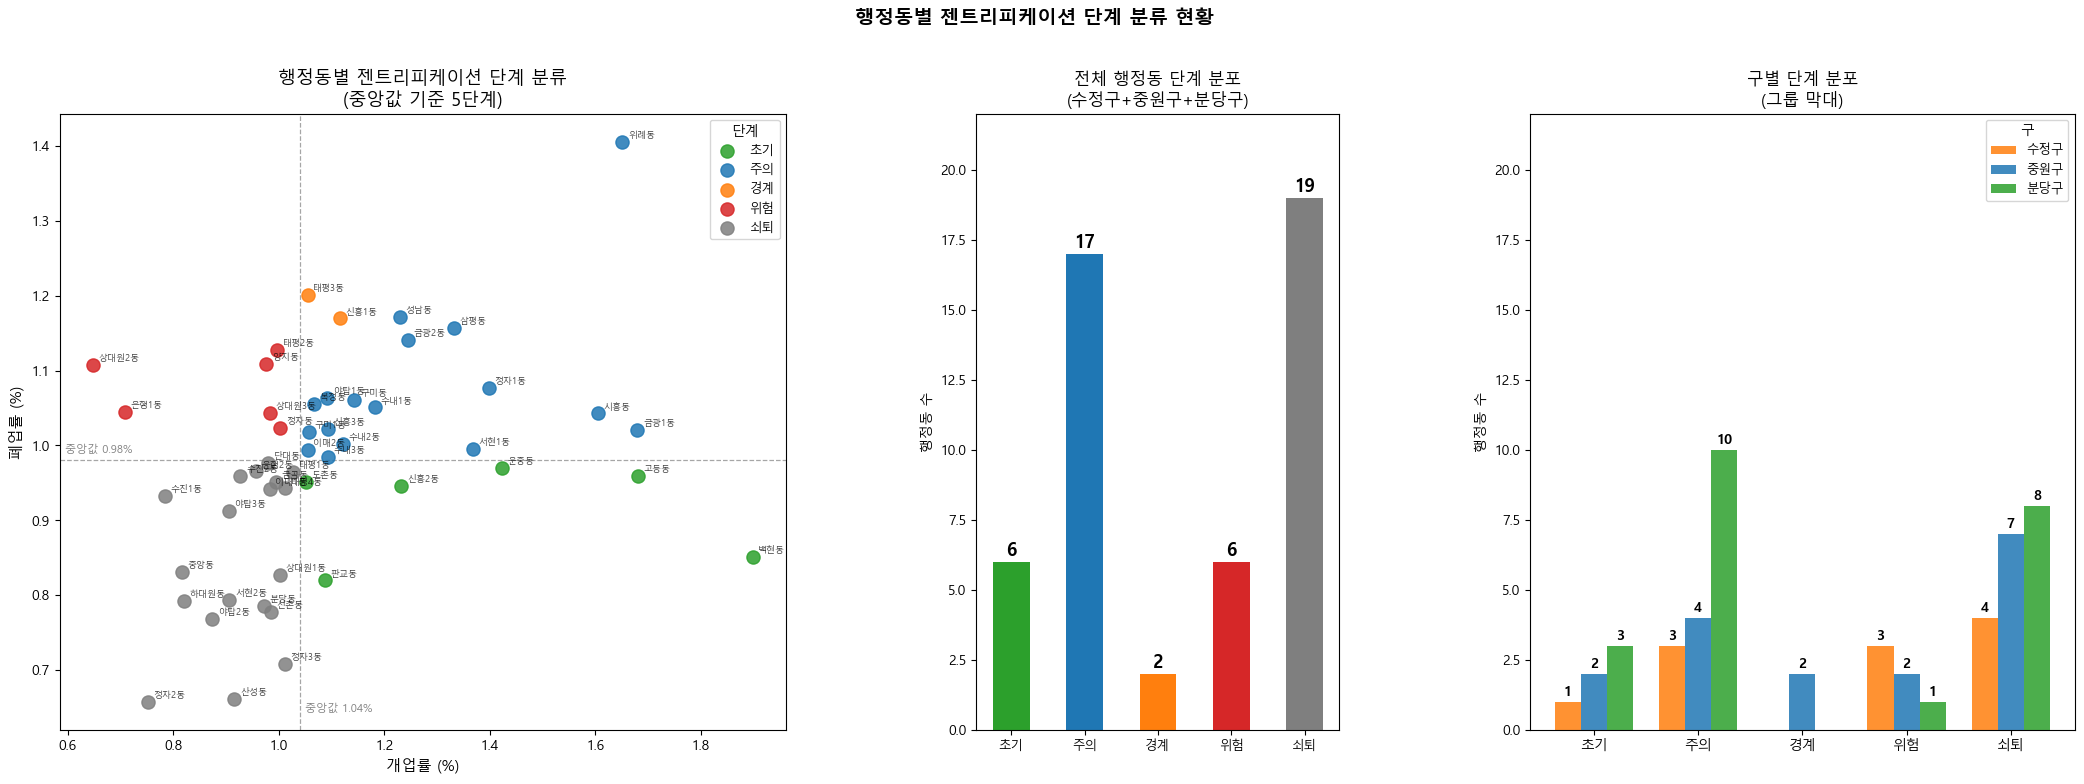

In [54]:
# ── 시각화 ───────────────────────────────────────────────────────────
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(26, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_scatter = fig.add_subplot(gs[0])
ax_total   = fig.add_subplot(gs[1])
ax_gu      = fig.add_subplot(gs[2])

# ── 왼쪽: 개업률 vs 폐업률 산점도 ────────────────────────────────────
for stage in stage_order:
    grp = dong[dong["젠트리피케이션_단계"] == stage]
    ax_scatter.scatter(grp["개업률"], grp["폐업률"],
                       label=stage, color=stage_colors[stage], s=90, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        ax_scatter.annotate(row["행정동명"], (row["개업률"], row["폐업률"]),
                            fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_scatter.axvline(med_open,  color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_scatter.axhline(med_close, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_scatter.text(med_open + 0.01, ax_scatter.get_ylim()[0] + 0.02,
                f"중앙값 {med_open:.2f}%", fontsize=8, color="gray", va="bottom")
ax_scatter.text(ax_scatter.get_xlim()[0] + 0.01, med_close + 0.01,
                f"중앙값 {med_close:.2f}%", fontsize=8, color="gray")
ax_scatter.set_xlabel("개업률 (%)", fontsize=11)
ax_scatter.set_ylabel("폐업률 (%)", fontsize=11)
ax_scatter.set_title("행정동별 젠트리피케이션 단계 분류\n(중앙값 기준 5단계)", fontsize=13)
ax_scatter.legend(title="단계", fontsize=9)

# ── 중간: 전체 행정동 단계 분포 ──────────────────────────────────────
counts_total = [dong["젠트리피케이션_단계"].value_counts().get(s, 0) for s in stage_order]
bars = ax_total.bar(stage_order, counts_total,
                    color=[stage_colors[s] for s in stage_order], width=0.5)
for bar, v in zip(bars, counts_total):
    ax_total.text(bar.get_x() + bar.get_width() / 2, v + 0.08, str(v),
                  ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_total.set_ylim(0, max(counts_total) + 3)
ax_total.set_title("전체 행정동 단계 분포\n(수정구+중원구+분당구)", fontsize=12)
ax_total.set_ylabel("행정동 수")
ax_total.tick_params(axis="x", labelsize=9)

# ── 오른쪽: 구별 단계 분포 (그룹 막대) ───────────────────────────────
gu_list   = ["수정구", "중원구", "분당구"]
gu_colors = {"수정구": "#ff7f0e", "중원구": "#1f77b4", "분당구": "#2ca02c"}

x     = np.arange(len(stage_order))
width = 0.25

for i, gu in enumerate(gu_list):
    counts_gu = [
        dong[(dong["구명"] == gu) & (dong["젠트리피케이션_단계"] == s)].shape[0]
        for s in stage_order
    ]
    bars_gu = ax_gu.bar(x + (i - 1) * width, counts_gu,
                        width=width, label=gu, color=gu_colors[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")

ax_gu.set_xticks(x)
ax_gu.set_xticklabels(stage_order, fontsize=10)
ax_gu.set_title("구별 단계 분포\n(그룹 막대)", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_total) + 3)

plt.suptitle("행정동별 젠트리피케이션 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 그래프 해석

- 위험(개업률은 낮고, 폐업률은 높음)에 해당하는 6개의 행정동 중 5개가 원도심에 해당됨
- 원도심 28개 행정동 중 14개가 위험 혹은 진행 단계임
- 분당구도 진행 단계인 행정동이 10개가 관측됨. 하지만 안정 단계도 그만큼 많은 상황

---

# 2. 프랜차이즈수 변화

## 행정동별 분기별 프랜차이즈 침투율

- 집계: 분기별 `fran_cnt` / `mer_cnt` × 100
- 상위 5개 기준: **전체 기간(2023 Q1 ~ 2025 Q4) 평균 침투율**
  - 단일 분기 이상치에 흔들리지 않고 구조적으로 프랜차이즈 비중이 높은 지역을 선별
  - 최신 분기(2025 Q4) 기준으로 뽑으면 일시적 급등 지역이 포함될 수 있어 평균이 더 안정적

In [55]:
# ── 분기별 프랜차이즈 침투율 계산 ────────────────────────────────────

df_eda["quarter"] = df_eda["ta_ym"].dt.quarter
df_eda["year"]    = df_eda["ta_ym"].dt.year
df_eda["분기"]    = df_eda["year"].astype(str) + "-Q" + df_eda["quarter"].astype(str)

# 행정동 + 분기별 집계
q_agg = (
    df_eda.groupby(["행정동명", "구명", "분기"])[["fran_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
q_agg["침투율"] = q_agg["fran_cnt"] / q_agg["mer_cnt"] * 100

# 분기 순서 정렬용 키
quarter_order = sorted(q_agg["분기"].unique())
q_agg["분기"] = pd.Categorical(q_agg["분기"], categories=quarter_order, ordered=True)
q_agg = q_agg.sort_values(["행정동명", "분기"])

# 피벗 테이블 형태로 출력 (행=행정동, 열=분기)
pivot_q = q_agg.pivot_table(index=["행정동명", "구명"], columns="분기", values="침투율")
pivot_q.columns = [str(c) for c in pivot_q.columns]
pivot_q = pivot_q.round(2)

# 전체 기간 평균 침투율 컬럼 추가 (상위 기준)
pivot_q["평균침투율"] = pivot_q.mean(axis=1).round(2)
pivot_q = pivot_q.sort_values("평균침투율", ascending=False)

print(f"행정동 수: {len(pivot_q)}개  /  분기 수: {len(quarter_order)}개")
print()
display(pivot_q.head())


행정동 수: 50개  /  분기 수: 12개



,,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,평균침투율
행정동명,구명,,,,,,,,,,,,,
고등동,중원구,7.94,8.17,8.24,8.75,9.09,8.61,7.26,7.35,6.51,6.75,6.17,6.32,7.60
위례동,중원구,7.61,7.88,7.76,7.79,7.79,8.09,7.34,7.29,6.46,6.67,6.10,6.07,7.24
삼평동,분당구,6.69,6.77,7.11,7.34,7.62,7.86,7.11,7.29,6.74,6.89,6.21,6.46,7.01
수내3동,분당구,6.70,6.98,6.94,6.99,7.15,7.21,6.78,6.99,6.44,6.72,6.45,6.33,6.81
정자2동,분당구,6.12,6.44,6.79,7.35,7.22,7.17,6.37,7.13,6.75,6.82,6.59,6.42,6.76


상위 5개 행정동 (전체 기간 평균 침투율 기준):
          평균침투율
행정동명 구명        
고등동  중원구   7.60
위례동  중원구   7.24
삼평동  분당구   7.01
수내3동 분당구   6.81
정자2동 분당구   6.76



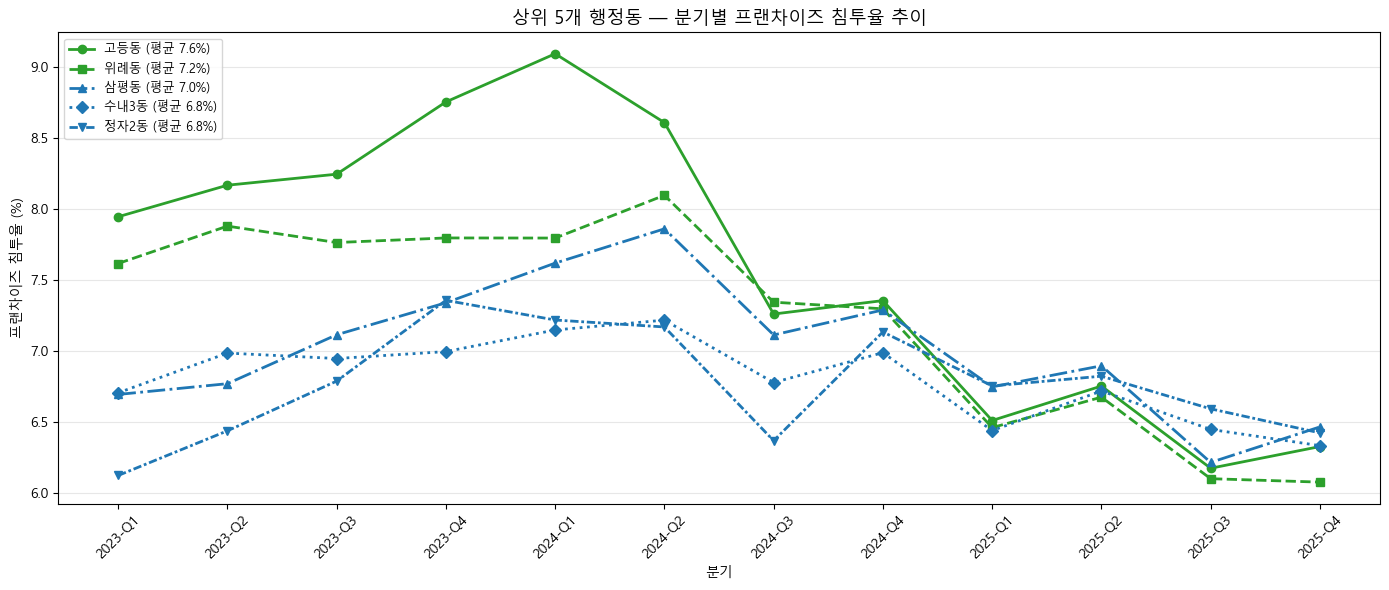

In [56]:
# ── 상위 5개 행정동 분기별 침투율 라인 차트 ─────────────────────────

top5 = pivot_q.nlargest(5, "평균침투율").index.get_level_values("행정동명").tolist()
top5_data = q_agg[q_agg["행정동명"].isin(top5)].copy()

print("상위 5개 행정동 (전체 기간 평균 침투율 기준):")
print(pivot_q.loc[pivot_q.index.get_level_values("행정동명").isin(top5), ["평균침투율"]].to_string())
print()

gu_colors_fran = {"분당구": "#1f77b4", "수정구": "#ff7f0e", "중원구": "#2ca02c"}
markers = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, dong_name in enumerate(top5):
    grp = top5_data[top5_data["행정동명"] == dong_name].sort_values("분기")
    gu = grp["구명"].iloc[0]
    avg = pivot_q.loc[pivot_q.index.get_level_values("행정동명") == dong_name, "평균침투율"].values[0]
    label = f"{dong_name} (평균 {avg:.1f}%)"
    ax.plot(
        grp["분기"].astype(str), grp["침투율"],
        marker=markers[i], linewidth=2, markersize=6,
        color=gu_colors_fran[gu], label=label,
        linestyle=["-","--","-.",":",(0,(3,1,1,1))][i]
    )

ax.set_title("상위 5개 행정동 — 분기별 프랜차이즈 침투율 추이", fontsize=13)
ax.set_xlabel("분기")
ax.set_ylabel("프랜차이즈 침투율 (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 프랜차이즈 침투율 기반 젠트리피케이션 단계 분류

개업률·폐업률과 동일하게, 중앙값 기준 4사분면 중 **위험 사분면(침투율↑ 기울기↓)** 을 내부 기울기 중앙값으로 추가 분리해 5단계를 도출합니다.

| 단계 | 평균 침투율 | 분기 기울기 | 의미 |
|---|---|---|---|
| 초기 | 낮음 | 낮음 | 프랜차이즈 영향 없음, 소상공인 중심 상권 |
| 주의 | 낮음 | 높음 | 프랜차이즈 진입 시작, 소상공인 위협 초기 |
| 경계 | 높음 | 높음 | 프랜차이즈가 소상공인을 빠르게 대체 중 |
| 위험 | 높음 | 낮음 | 포화 상태, 소상공인 대부분 이탈 완료 |
| 쇠퇴 | 높음 | 매우 낮음 | 포화 후 급감, 프랜차이즈마저 이탈하는 쇠퇴 구간 |

In [57]:
# 분기별 침투율 기울기 계산
from scipy.stats import linregress

def quarterly_slope(grp):
    grp = grp.sort_values("분기")
    x = list(range(len(grp)))
    slope, *_ = linregress(x, grp["침투율"].tolist())
    return slope

slope_q = (
    q_agg.groupby("행정동명")
    .apply(quarterly_slope)
    .reset_index()
    .rename(columns={0: "기울기"})
)

fran_q_stage = (
    pivot_q[["평균침투율"]]
    .reset_index()
    .merge(slope_q, on="행정동명")
)

med_rate  = fran_q_stage["평균침투율"].median()
med_slope = fran_q_stage["기울기"].median()

# 위험 사분면(침투율↑ 기울기↓) 내부를 기울기 중앙값으로 추가 분리 → 위험/쇠퇴
위험_mask = (fran_q_stage["평균침투율"] >= med_rate) & (fran_q_stage["기울기"] < med_slope)
med_위험_slope = fran_q_stage.loc[위험_mask, "기울기"].median()

def classify(row):
    hi_r = row["평균침투율"] >= med_rate
    hi_s = row["기울기"]     >= med_slope
    if not hi_r and not hi_s: return "초기"   # 낮음+감소 → 아직 영향 없음
    if not hi_r and hi_s:     return "주의"   # 낮음+상승 → 진입 시작
    if hi_r and hi_s:         return "경계"   # 높음+상승 → 빠른 대체
    # hi_r and not hi_s → 위험 사분면: 기울기로 위험/쇠퇴 추가 분리
    if row["기울기"] < med_위험_slope:        return "쇠퇴"
    return "위험"

fran_q_stage["단계"] = fran_q_stage.apply(classify, axis=1)

stage_colors = {
    "초기": "#2ca02c",
    "주의": "#1f77b4",
    "경계": "#ff7f0e",
    "위험": "#d62728",
    "쇠퇴": "#7f7f7f",
}
stage_order = ["초기", "주의", "경계", "위험", "쇠퇴"]

print(f"기준 중앙값 — 평균 침투율: {med_rate:.2f}%  /  분기 기울기: {med_slope:.4f}")
print(f"위험 사분면 내부 기울기 중앙값: {med_위험_slope:.4f}")
print()
print("=== 행정동별 단계 분류 결과 ===")
print(
    fran_q_stage[["행정동명", "구명", "평균침투율", "기울기", "단계"]]
    .sort_values(["단계", "평균침투율"], ascending=[True, False])
    .round(4)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 ===")
print(fran_q_stage["단계"].value_counts()[stage_order])

기준 중앙값 — 평균 침투율: 5.21%  /  분기 기울기: -0.0180
위험 사분면 내부 기울기 중앙값: -0.0614

=== 행정동별 단계 분류 결과 ===
 행정동명  구명  평균침투율     기울기 단계
 정자2동 분당구   6.76  0.0030 경계
  시흥동 중원구   6.58  0.1360 경계
  운중동 분당구   6.31  0.0123 경계
  산성동 중원구   6.29  0.1838 경계
 신흥2동 중원구   6.08  0.0826 경계
  분당동 분당구   5.91  0.0592 경계
 금광1동 수정구   5.84  0.1621 경계
 야탑1동 분당구   5.76 -0.0082 경계
 신흥3동 중원구   5.50 -0.0144 경계
  도촌동 수정구   5.44  0.0252 경계
  복정동 중원구   5.33  0.0001 경계
  고등동 중원구   7.60 -0.2237 쇠퇴
  위례동 중원구   7.24 -0.1731 쇠퇴
  판교동 분당구   6.15 -0.1047 쇠퇴
 수내1동 분당구   5.81 -0.1524 쇠퇴
 금광2동 수정구   5.79 -0.0718 쇠퇴
 정자3동 분당구   5.70 -0.0737 쇠퇴
 태평1동 중원구   5.55 -0.0851 쇠퇴
  삼평동 분당구   7.01 -0.0480 위험
 수내3동 분당구   6.81 -0.0498 위험
  양지동 중원구   6.21 -0.0311 위험
  구미동 분당구   5.72 -0.0614 위험
 서현1동 분당구   5.55 -0.0589 위험
 신흥1동 중원구   5.27 -0.0292 위험
 정자1동 분당구   5.21 -0.0251 위험
  백현동 분당구   5.21 -0.0260 위험
  금곡동 분당구   5.11 -0.0073 주의
 구미1동 분당구   5.04 -0.0169 주의
 은행2동 수정구   5.00  0.0369 주의
  신촌동 중원구   4.78  0.0212 주의
 이매1동 분당구   4.77 -0.0089 주의
 태평3동 중원구  

C:\Users\rmstn\AppData\Local\Temp\ipykernel_14968\3007631311.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


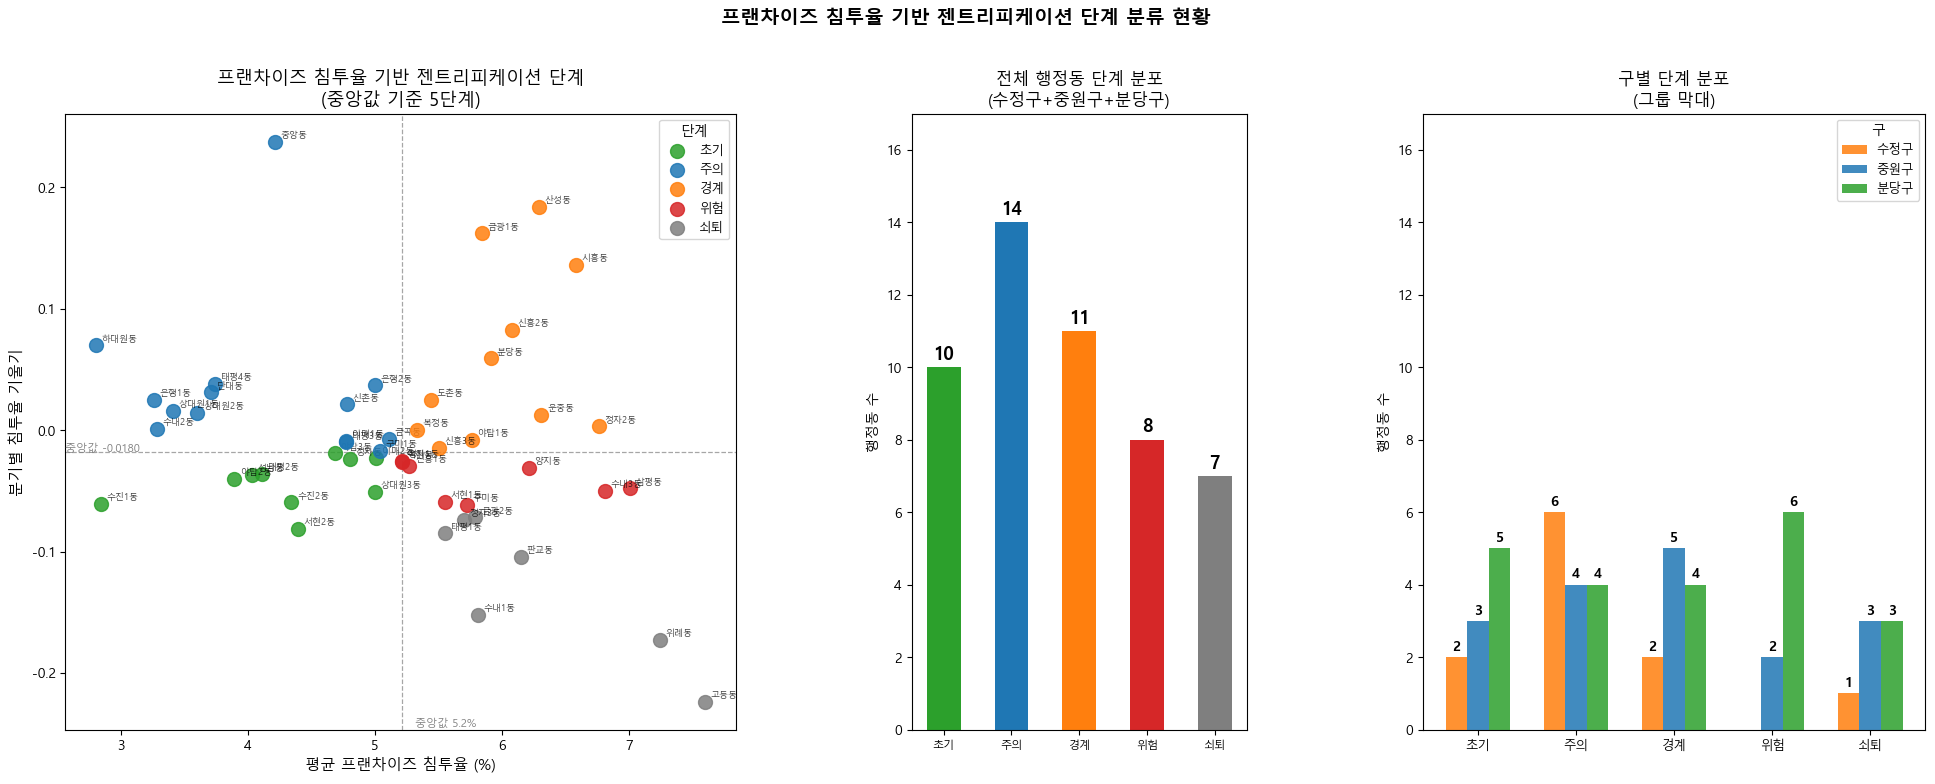

In [58]:
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(24, 8))
gs  = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_sc  = fig.add_subplot(gs[0])
ax_tot = fig.add_subplot(gs[1])
ax_gu  = fig.add_subplot(gs[2])

for stage in stage_order:
    grp = fran_q_stage[fran_q_stage["단계"] == stage]
    ax_sc.scatter(grp["평균침투율"], grp["기울기"],
                  label=stage, color=stage_colors[stage], s=100, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        ax_sc.annotate(row["행정동명"], (row["평균침투율"], row["기울기"]),
                       fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_sc.axvline(med_rate,  color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.axhline(med_slope, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.text(med_rate + 0.1, ax_sc.get_ylim()[0],
           f"중앙값 {med_rate:.1f}%", fontsize=8, color="gray", va="bottom")
ax_sc.text(ax_sc.get_xlim()[0], med_slope + 0.0002,
           f"중앙값 {med_slope:.4f}", fontsize=8, color="gray")
ax_sc.set_xlabel("평균 프랜차이즈 침투율 (%)", fontsize=11)
ax_sc.set_ylabel("분기별 침투율 기울기", fontsize=11)
ax_sc.set_title("프랜차이즈 침투율 기반 젠트리피케이션 단계\n(중앙값 기준 5단계)", fontsize=13)
ax_sc.legend(title="단계", fontsize=9)

counts_total = [fran_q_stage["단계"].value_counts().get(s, 0) for s in stage_order]
bars = ax_tot.bar(stage_order, counts_total,
                  color=[stage_colors[s] for s in stage_order], width=0.5)
for bar, v in zip(bars, counts_total):
    ax_tot.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v),
                ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_tot.set_ylim(0, max(counts_total) + 3)
ax_tot.set_title("전체 행정동 단계 분포\n(수정구+중원구+분당구)", fontsize=12)
ax_tot.set_ylabel("행정동 수")
ax_tot.tick_params(axis="x", labelsize=8)

gu_list    = ["수정구", "중원구", "분당구"]
gu_palette = {"수정구": "#ff7f0e", "중원구": "#1f77b4", "분당구": "#2ca02c"}
x = np.arange(len(stage_order))
width = 0.22
for i, gu in enumerate(gu_list):
    counts_gu = [
        fran_q_stage[(fran_q_stage["구명"] == gu) & (fran_q_stage["단계"] == s)].shape[0]
        for s in stage_order
    ]
    bars_gu = ax_gu.bar(x + (i - 1) * width, counts_gu,
                        width=width, label=gu, color=gu_palette[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_gu.set_xticks(x)
ax_gu.set_xticklabels(stage_order, fontsize=9)
ax_gu.set_title("구별 단계 분포\n(그룹 막대)", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_total) + 3)

plt.suptitle("프랜차이즈 침투율 기반 젠트리피케이션 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 해석

- 프랜차이즈 침투율 분기별 추이와 단계별 분류 현황을 살펴보았을 때 가장 많은 행정동이 위험 단계에 속함
- 이는 프렌차이즈 침투가 정점을 찍고 내려오는 구간으로, 상권 자체가 수축 중임을 의미
- 분당구는 위험 단계에 속하는 행정동이 가장 많음 이는 이미 구조적 포화임을 의미함
- 수정구에 해당하는 행정동은 아직 안정, 초기에 분포해 있는 단계

---

# 3. 업종 다양성

## 분석 방법론: 섀넌 다양성 지수 (Shannon Entropy)

| 지표 | 공식 |
|---|---|
| 다양성 지수 H | H = −Σ (p_i × ln p_i) |
| p_i | 해당 소분류 업종의 가맹점 수 / 전체 가맹점 수 |

- 집계 기준: **소분류 업종(`card_tpbuz_nm_2`)** — 대분류는 너무 거칠고, 소분류로 실제 업종 쏠림을 포착
- H값이 높을수록 업종이 고르게 분포 (다양), 낮을수록 특정 업종 집중 (단순)
- **안정성 필터**: 행정동 × 분기별 가맹점 합계 50개 미만 조합 제외
- 논문에서도 사용되는 지수 : https://kpaj.or.kr/_PR/view/?aidx=44988&bidx=4067

In [59]:
# ── 섀넌 다양성 지수 계산 (소분류 기준, 행정동 × 분기) ───────────────
from scipy.stats import entropy as scipy_entropy

# 행정동 + 분기 + 소분류별 가맹점 수 집계
div_agg = (
    df_eda.groupby(["행정동명", "구명", "분기", "card_tpbuz_nm_2"])["mer_cnt"]
    .sum()
    .reset_index()
)

# 안정성 필터: 행정동 × 분기 합계 50개 이상만 유지
valid_pairs = (
    df_eda.groupby(["행정동명", "분기"])["mer_cnt"]
    .sum()
    .reset_index()
    .query("mer_cnt >= 50")[["행정동명", "분기"]]
)
div_agg = div_agg.merge(valid_pairs, on=["행정동명", "분기"])

# 섀넌 엔트로피 (자연로그 기준)
def shannon_h(group):
    counts = group["mer_cnt"].values
    total  = counts.sum()
    if total == 0:
        return np.nan
    return scipy_entropy(counts / total, base=np.e)

div_h = (
    div_agg.groupby(["행정동명", "구명", "분기"])
    .apply(shannon_h)
    .reset_index()
    .rename(columns={0: "다양성지수"})
)

div_h["분기"] = pd.Categorical(div_h["분기"], categories=quarter_order, ordered=True)
div_h = div_h.sort_values(["행정동명", "분기"])

print(f"유효 행정동 × 분기 조합: {len(div_h):,}개")
print()
print("=== 다양성 지수 요약 통계 ===")
print(div_h["다양성지수"].describe().round(4))

유효 행정동 × 분기 조합: 600개

=== 다양성 지수 요약 통계 ===
count    600.0000
mean       3.5644
std        0.1079
min        3.1913
25%        3.5181
50%        3.5815
75%        3.6376
max        3.8078
Name: 다양성지수, dtype: float64


다양성 하위 5개 행정동 (전체 기간 평균 기준):
행정동명  구명  평균다양성
 신촌동 중원구 3.2535
수진1동 중원구 3.3180
수내2동 분당구 3.3285
은행1동 수정구 3.3365
 고등동 중원구 3.4020


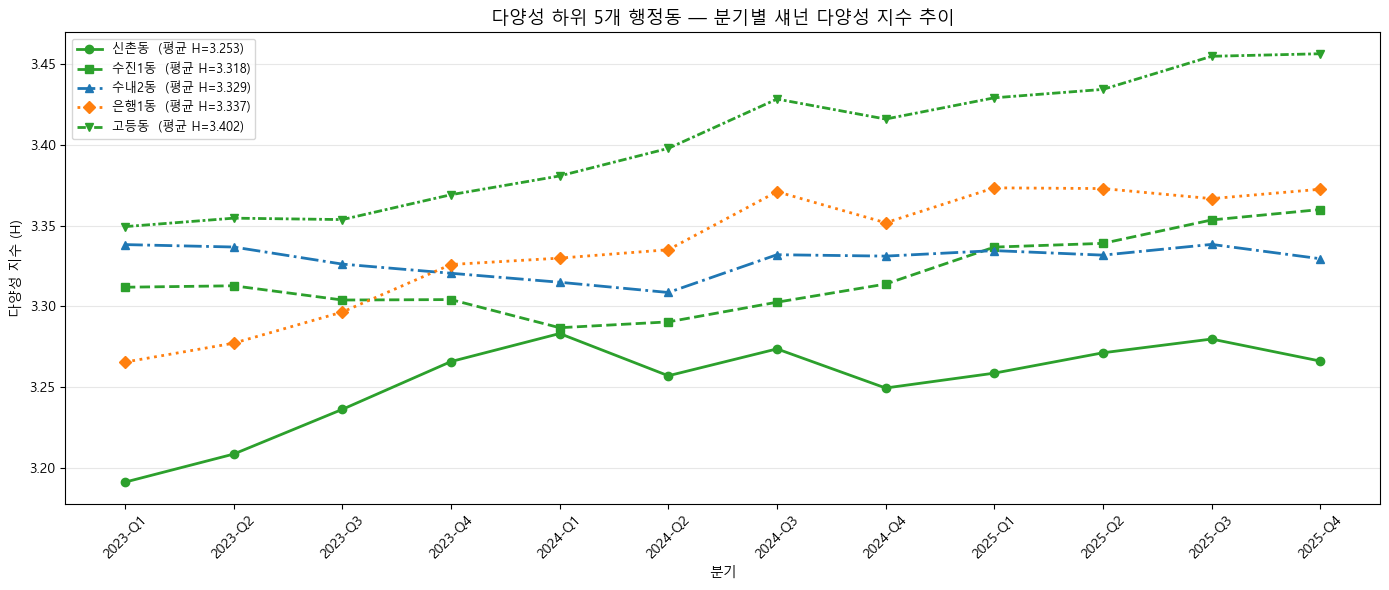

In [60]:
# ── 다양성 하위 5개 행정동 분기별 추이 라인 차트 ─────────────────────
dong_avg = (
    div_h.groupby(["행정동명", "구명"])["다양성지수"]
    .mean()
    .reset_index()
    .rename(columns={"다양성지수": "평균다양성"})
    .sort_values("평균다양성")
)

bottom5 = dong_avg.head(5)["행정동명"].tolist()
bottom5_data = div_h[div_h["행정동명"].isin(bottom5)].copy()

print("다양성 하위 5개 행정동 (전체 기간 평균 기준):")
print(dong_avg.head(5)[["행정동명", "구명", "평균다양성"]].round(4).to_string(index=False))

gu_colors_div2 = {"분당구": "#1f77b4", "수정구": "#ff7f0e", "중원구": "#2ca02c"}
markers = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, dong_name in enumerate(bottom5):
    grp = bottom5_data[bottom5_data["행정동명"] == dong_name].sort_values("분기")
    gu  = grp["구명"].iloc[0]
    avg = dong_avg.loc[dong_avg["행정동명"] == dong_name, "평균다양성"].values[0]
    ax.plot(
        grp["분기"].astype(str), grp["다양성지수"],
        marker=markers[i], linewidth=2, markersize=6,
        color=gu_colors_div2[gu],
        label=f"{dong_name}  (평균 H={avg:.3f})",
        linestyle=["-", "--", "-.", ":", (0, (3, 1, 1, 1))][i],
    )

ax.set_title("다양성 하위 5개 행정동 — 분기별 섀넌 다양성 지수 추이", fontsize=13)
ax.set_xlabel("분기")
ax.set_ylabel("다양성 지수 (H)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 업종 다양성 기반 젠트리피케이션 단계 분류

개폐업률·프랜차이즈와 동일하게, 중앙값 기준 4사분면 중 **위험 사분면(다양성↓ 기울기↓)** 을 내부 기울기 중앙값으로 추가 분리해 5단계를 도출합니다.

| 단계 | 평균 H | 기울기 | 의미 |
|---|---|---|---|
| 초기 | 높음 | 양수 | 다양한 업종이 더 늘어나는 건강한 상권 — 젠트리피케이션 이전 |
| 주의 | 낮음 | 양수 | 단순하지만 회복 중 — 재편 초기 단계 |
| 경계 | 높음 | 음수 | 다양했지만 획일화 시작 — 진행 신호 |
| 위험 | 낮음 | 음수 | 이미 단순하고 더 단순해지는 중 — 소상공인 이탈 |
| 쇠퇴 | 낮음 | 매우 낮음 | 공동화 심화, 대체 업종조차 유입되지 않는 상태 |

In [61]:
# ── 행정동별 평균 다양성 + 분기 기울기 계산 → 5단계 분류 ─────────────
from scipy.stats import linregress

pivot_div = div_h.pivot_table(index=["행정동명", "구명"], columns="분기", values="다양성지수")
pivot_div.columns = [str(c) for c in pivot_div.columns]
pivot_div["평균다양성"] = pivot_div.mean(axis=1).round(4)

def calc_slope_div(grp):
    grp = grp.dropna(subset=["다양성지수"]).sort_values("분기")
    if len(grp) < 3:
        return np.nan
    x = list(range(len(grp)))
    slope, *_ = linregress(x, grp["다양성지수"].tolist())
    return slope

slope_div = (
    div_h.groupby("행정동명")
    .apply(calc_slope_div)
    .reset_index()
    .rename(columns={0: "기울기"})
)

div_summary = (
    pivot_div[["평균다양성"]]
    .reset_index()
    .merge(slope_div, on="행정동명")
)

med_h_val = div_summary["평균다양성"].median()
med_s_val = div_summary["기울기"].median()

# 위험 사분면(다양성↓ 기울기↓) 내부를 기울기 중앙값으로 추가 분리 → 위험/쇠퇴
위험_mask_div = (div_summary["평균다양성"] < med_h_val) & (div_summary["기울기"] < med_s_val)
med_위험_slope_div = div_summary.loc[위험_mask_div, "기울기"].median()

def classify_div(row):
    hi_h = row["평균다양성"] >= med_h_val
    hi_s = row["기울기"]     >= med_s_val
    if hi_h and hi_s:     return "초기"   # 다양↑ 증가↑ → 건강한 상권
    if not hi_h and hi_s: return "주의"   # 다양↓ 증가↑ → 단순하지만 회복 중
    if hi_h and not hi_s: return "경계"   # 다양↑ 감소↓ → 획일화 진행
    # not hi_h and not hi_s → 위험 사분면: 기울기로 위험/쇠퇴 추가 분리
    if row["기울기"] < med_위험_slope_div: return "쇠퇴"
    return "위험"

div_summary["단계"] = div_summary.apply(classify_div, axis=1)

stage_colors_div = {
    "초기": "#2ca02c",
    "주의": "#1f77b4",
    "경계": "#ff7f0e",
    "위험": "#d62728",
    "쇠퇴": "#7f7f7f",
}
stage_order_div = ["초기", "주의", "경계", "위험", "쇠퇴"]

print(f"기준 중앙값 — 평균 다양성: {med_h_val:.4f}  /  기울기: {med_s_val:.6f}")
print(f"위험 사분면 내부 기울기 중앙값: {med_위험_slope_div:.6f}")
print()
print("=== 행정동별 업종 다양성 단계 분류 ===")
print(
    div_summary[["행정동명", "구명", "평균다양성", "기울기", "단계"]]
    .sort_values(["단계", "평균다양성"], ascending=[True, False])
    .round(4)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 ===")
print(div_summary["단계"].value_counts()[stage_order_div].to_string())

기준 중앙값 — 평균 다양성: 3.5783  /  기울기: 0.000975
위험 사분면 내부 기울기 중앙값: -0.000660

=== 행정동별 업종 다양성 단계 분류 ===
 행정동명  구명  평균다양성     기울기 단계
 수진2동 중원구 3.7748 -0.0031 경계
  구미동 분당구 3.7147 -0.0019 경계
  금곡동 분당구 3.6681  0.0004 경계
 이매1동 분당구 3.6666 -0.0013 경계
 금광2동 수정구 3.6576 -0.0018 경계
 야탑1동 분당구 3.6492 -0.0042 경계
 수내1동 분당구 3.6471 -0.0005 경계
  도촌동 수정구 3.6414 -0.0025 경계
  위례동 중원구 3.6391 -0.0022 경계
 서현1동 분당구 3.6364 -0.0043 경계
 구미1동 분당구 3.6295 -0.0009 경계
  복정동 중원구 3.6240 -0.0081 경계
  삼평동 분당구 3.6069 -0.0034 경계
 정자1동 분당구 3.6045 -0.0011 경계
  성남동 수정구 3.6029 -0.0011 경계
  정자동 분당구 3.6017 -0.0000 경계
 서현2동 분당구 3.5801 -0.0019 경계
상대원2동 수정구 3.5765 -0.0061 쇠퇴
 신흥3동 중원구 3.5573 -0.0037 쇠퇴
 신흥1동 중원구 3.4879 -0.0016 쇠퇴
  시흥동 중원구 3.4850 -0.0019 쇠퇴
  양지동 중원구 3.5409  0.0003 위험
  백현동 분당구 3.5340  0.0009 위험
상대원1동 수정구 3.4935  0.0009 위험
 수내2동 분당구 3.3285  0.0003 위험
 태평3동 중원구 3.5653  0.0011 주의
 태평1동 중원구 3.5650  0.0044 주의
  운중동 분당구 3.5594  0.0049 주의
  중앙동 수정구 3.5551  0.0065 주의
  판교동 분당구 3.5460  0.0016 주의
  분당동 분당구 3.5426  0.0030 주의
 태평4동 

C:\Users\rmstn\AppData\Local\Temp\ipykernel_14968\4083064040.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


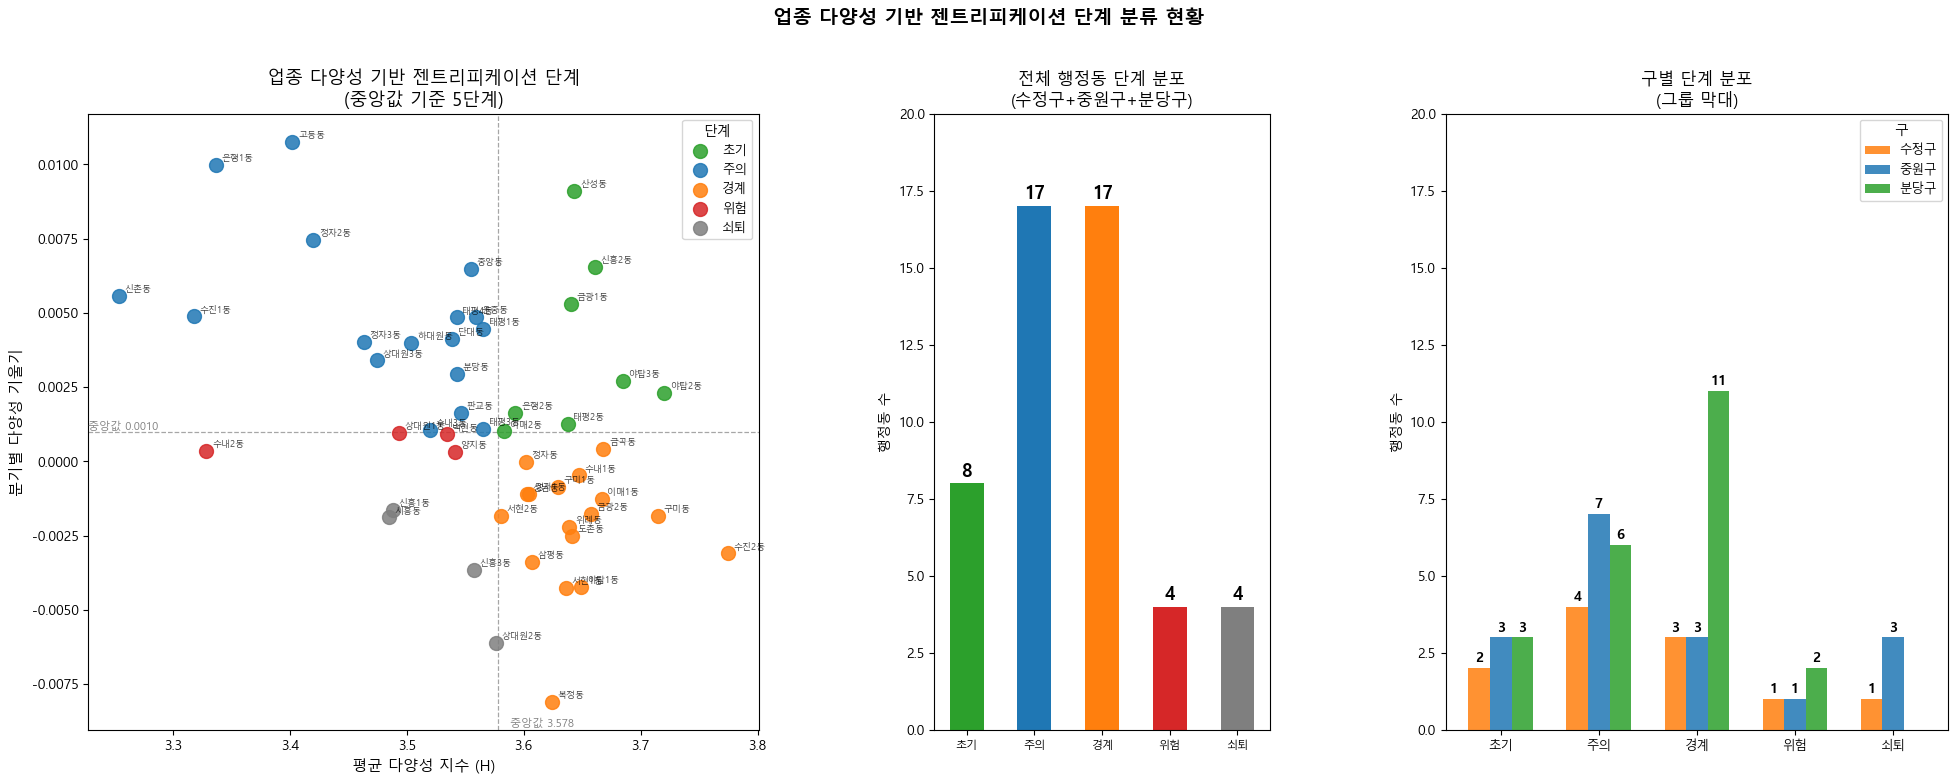

In [62]:
# ── 시각화: 산점도 + 전체 분포 + 구별 분포 ────────────────────────────
from matplotlib.patches import Patch

fig = plt.figure(figsize=(24, 8))
gs  = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_sc  = fig.add_subplot(gs[0])
ax_tot = fig.add_subplot(gs[1])
ax_gu  = fig.add_subplot(gs[2])

for stage in stage_order_div:
    grp = div_summary[div_summary["단계"] == stage]
    ax_sc.scatter(grp["평균다양성"], grp["기울기"],
                  label=stage, color=stage_colors_div[stage], s=100, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        ax_sc.annotate(row["행정동명"], (row["평균다양성"], row["기울기"]),
                       fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_sc.axvline(med_h_val, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.axhline(med_s_val, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.text(med_h_val + 0.01, ax_sc.get_ylim()[0],
           f"중앙값 {med_h_val:.3f}", fontsize=8, color="gray", va="bottom")
ax_sc.text(ax_sc.get_xlim()[0], med_s_val + 0.0001,
           f"중앙값 {med_s_val:.4f}", fontsize=8, color="gray")
ax_sc.set_xlabel("평균 다양성 지수 (H)", fontsize=11)
ax_sc.set_ylabel("분기별 다양성 기울기", fontsize=11)
ax_sc.set_title("업종 다양성 기반 젠트리피케이션 단계\n(중앙값 기준 5단계)", fontsize=13)
ax_sc.legend(title="단계", fontsize=9)

counts_div = [div_summary["단계"].value_counts().get(s, 0) for s in stage_order_div]
bars = ax_tot.bar(stage_order_div, counts_div,
                  color=[stage_colors_div[s] for s in stage_order_div], width=0.5)
for bar, v in zip(bars, counts_div):
    ax_tot.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_tot.set_ylim(0, max(counts_div) + 3)
ax_tot.set_title("전체 행정동 단계 분포\n(수정구+중원구+분당구)", fontsize=12)
ax_tot.set_ylabel("행정동 수")
ax_tot.tick_params(axis="x", labelsize=8)

gu_list    = ["수정구", "중원구", "분당구"]
gu_palette = {"수정구": "#ff7f0e", "중원구": "#1f77b4", "분당구": "#2ca02c"}
x = np.arange(len(stage_order_div))
width = 0.22
for i, gu in enumerate(gu_list):
    counts_gu = [
        div_summary[(div_summary["구명"] == gu) & (div_summary["단계"] == s)].shape[0]
        for s in stage_order_div
    ]
    bars_gu = ax_gu.bar(x + (i - 1) * width, counts_gu,
                        width=width, label=gu, color=gu_palette[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_gu.set_xticks(x)
ax_gu.set_xticklabels(stage_order_div, fontsize=9)
ax_gu.set_title("구별 단계 분포\n(그룹 막대)", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_div) + 3)

plt.suptitle("업종 다양성 기반 젠트리피케이션 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

분석 대상 행정동: 4개 (진행 + 위험)

▲ 비중 증가 업종 Top 10:
                 2023-Q1  2025-Q4    변화
card_tpbuz_nm_2                        
한식                  9.44    10.25  0.81
커피/음료               4.54     5.17  0.63
인터넷쇼핑               5.16     5.66  0.50
별식/퓨전요리             0.44     0.90  0.46
방문판매                0.00     0.39  0.39
의복/의류               7.16     7.44  0.28
간이주점                0.75     0.98  0.23
취미/오락               0.90     1.13  0.23
일반스포츠               1.16     1.37  0.21
화장품소매               1.85     2.04  0.19

▼ 비중 감소 업종 Top 10:
                 2023-Q1  2025-Q4    변화
card_tpbuz_nm_2                        
제조/도매               6.77     5.94 -0.83
교통서비스               2.46     1.82 -0.64
인테리어/가정용품           3.74     3.24 -0.50
가전제품                3.07     2.74 -0.33
유아교육                1.51     1.25 -0.26
특화병원                0.77     0.59 -0.18
악기/공예               0.69     0.53 -0.16
차량관리/서비스            2.53     2.37 -0.16
중식                  0.64     0.51 -0.13
광고/인쇄/인화        

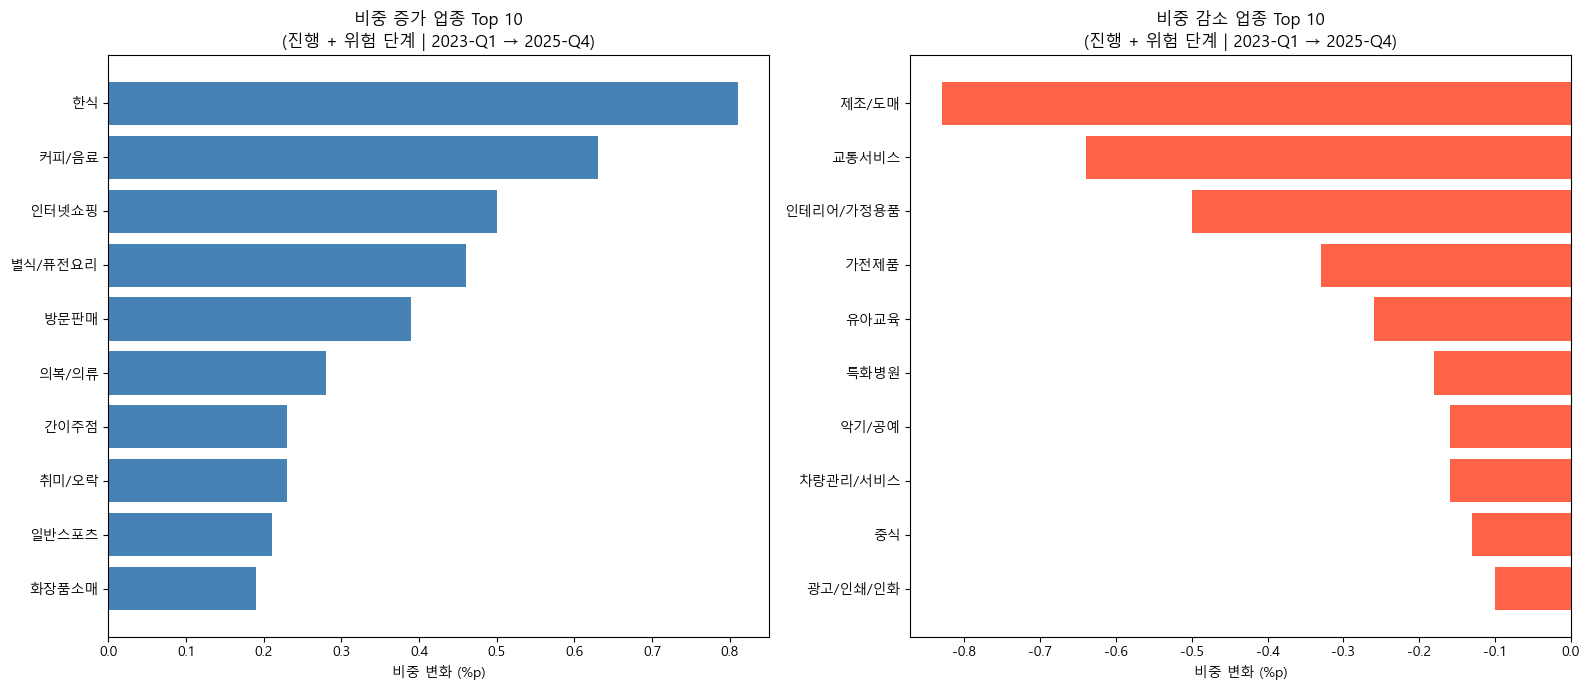

In [63]:
# ── 다양성 감소 지역 업종 교체 분석 ──────────────────────────────────
# "진행" + "위험" 단계 지역에서 2023-Q1 → 2025-Q4 업종 비중 변화

declining_dong = div_summary[div_summary["단계"].isin(["진행", "위험"])]["행정동명"].tolist()

df_23q1 = df_eda[(df_eda["분기"] == "2023-Q1") & (df_eda["행정동명"].isin(declining_dong))]
df_25q4 = df_eda[(df_eda["분기"] == "2025-Q4") & (df_eda["행정동명"].isin(declining_dong))]

def get_share(df_q):
    total = df_q["mer_cnt"].sum()
    if total == 0:
        return pd.Series(dtype=float)
    return (df_q.groupby("card_tpbuz_nm_2")["mer_cnt"].sum() / total * 100).round(2)

share_23 = get_share(df_23q1).rename("2023-Q1")
share_25 = get_share(df_25q4).rename("2025-Q4")
share_diff = pd.concat([share_23, share_25], axis=1).fillna(0)
share_diff["변화"] = (share_diff["2025-Q4"] - share_diff["2023-Q1"]).round(2)

print(f"분석 대상 행정동: {len(declining_dong)}개 (진행 + 위험)")
print()
print("▲ 비중 증가 업종 Top 10:")
print(share_diff.nlargest(10, "변화")[["2023-Q1", "2025-Q4", "변화"]].to_string())
print()
print("▼ 비중 감소 업종 Top 10:")
print(share_diff.nsmallest(10, "변화")[["2023-Q1", "2025-Q4", "변화"]].to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_inc = share_diff.nlargest(10, "변화")
top_dec = share_diff.nsmallest(10, "변화")

axes[0].barh(top_inc.index[::-1], top_inc["변화"][::-1], color="steelblue")
axes[0].set_title("비중 증가 업종 Top 10\n(진행 + 위험 단계 | 2023-Q1 → 2025-Q4)", fontsize=12)
axes[0].set_xlabel("비중 변화 (%p)")

axes[1].barh(top_dec.index[::-1], top_dec["변화"][::-1], color="tomato")
axes[1].set_title("비중 감소 업종 Top 10\n(진행 + 위험 단계 | 2023-Q1 → 2025-Q4)", fontsize=12)
axes[1].set_xlabel("비중 변화 (%p)")

plt.tight_layout()
plt.show()

# 그래프 해석

- 전체 행정동중에서 진행 + 위험의 합산이 25개로 성남시 전체 중 절반의 상권에서 업종 획일화가 진행 중임
- 분당구는 진행 단계에 17개 중 11개를 차지하고 있음 프랜차이즈 침투율과 교차 분석하면 프랜차이즈 위험 단계 + 업종 다양성 진행 단계이므로
- 소상공인이 빠진 자리를 프랜차이즈가 채우고 채운 프랜차이즈마저 획일화가 되는 상황임
- 진행·위험에 해당되는 행정동(25개) 내에서 비중이 증가한 업종은 한식·퓨전요리·카페 업종임 이는 외부 방문객을 겨냥하고 프랜차이즈 친화적인 업종임
- 반면 빠지는 업종은 음/식료품소매·의료·가전·유아교육인데 이는 거주 주민의 일상 생활 인프라가 악화되고 있음을 의미함 (젠트리피케이션의 교과서적 패턴)

---

# 4. 신생 점포 잔존율

## 행정동별 분기별 신생 점포 잔존율

- 집계: 분기별 `open_12_23_cnt(t) / open_11_cnt(t-12) × 100`
- 분모 안정성 필터: `open_11_cnt(t-12) ≥ 5`
- 분석 가능 기간: **2024-Q1부터** (12개월 lag 적용)
- 의미: 새로 들어온 점포가 1년 후 얼마나 남았는가 → **임대료·진입비용 충격의 선행 지표**
- 한계: 점포 ID 부재로 진짜 코호트 추적이 아닌 행정동×분기 집계 근사

In [64]:
# ── 분기별 신생 점포 잔존율 계산 ─────────────────────────────────────
import numpy as np

cohort_cols = ["open_11_cnt", "open_12_23_cnt", "mer_cnt", "close_cnt"]

# 행정동 + 분기별 집계
df_eda["분기"] = df_eda["year"].astype(str) + "-Q" + df_eda["quarter"].astype(str)
q_agg = (
    df_eda.groupby(["행정동명", "구명", "분기"])[cohort_cols]
    .sum()
    .reset_index()
)

# 순차 분기 인덱스 (2023-Q1=1, 2023-Q4=4, 2024-Q1=5, ...)
_year = q_agg["분기"].str[:4].astype(int)
_quarter = q_agg["분기"].str[-1].astype(int)
q_agg["_q_key"] = (_year - _year.min()) * 4 + _quarter
q_agg = q_agg.sort_values(["행정동명", "_q_key"]).reset_index(drop=True)

# 4분기(=1년) lag merge
lag = q_agg[["행정동명", "_q_key", "open_11_cnt"]].copy()
lag["_q_key"] = lag["_q_key"] + 4
lag = lag.rename(columns={"open_11_cnt": "open_11_lag4q"})
q_agg = q_agg.merge(lag, on=["행정동명", "_q_key"], how="left")

MIN_DENOM = 5
q_agg["잔존율"] = np.where(
    q_agg["open_11_lag4q"] >= MIN_DENOM,
    q_agg["open_12_23_cnt"] / q_agg["open_11_lag4q"] * 100,
    np.nan,
)

# 피벗 테이블 형태로 출력 (행=행정동, 열=분기)
pivot_surv = (
    q_agg.pivot_table(index=["행정동명", "구명"], columns="분기", values="잔존율")
    .round(1)
)
pivot_surv["평균잔존율"] = pivot_surv.mean(axis=1).round(1)
pivot_surv = pivot_surv.sort_values("평균잔존율", ascending=True)

print(f"산출 가능 행 수: {q_agg['잔존율'].notna().sum():,} / {len(q_agg):,}")
print(f"산출 가능 행정동 수: {pivot_surv['평균잔존율'].notna().sum()}")
print(f"전체 평균 잔존율: {pivot_surv['평균잔존율'].mean():.1f}%\n")

print("[ 행정동별 분기별 잔존율 (하위 10개 행정동) ]")
print(pivot_surv.dropna(subset=['평균잔존율']).head(10).to_string())


산출 가능 행 수: 400 / 600
산출 가능 행정동 수: 50
전체 평균 잔존율: 121.6%

[ 행정동별 분기별 잔존율 (하위 10개 행정동) ]
분기        2024-Q1  2024-Q2  2024-Q3  2024-Q4  2025-Q1  2025-Q2  2025-Q3  2025-Q4  평균잔존율
행정동명 구명                                                                                
산성동  중원구     84.9    122.4    111.1    101.3    100.0    107.1     87.2    107.5  102.7
단대동  중원구     95.8    103.9     92.8     90.8    106.8    113.0    105.0    120.4  103.6
태평4동 중원구     95.2    107.6     94.9    103.4    120.6    131.2    101.1    114.8  108.6
이매2동 분당구     85.9    108.9    101.0    136.4    119.3    120.0    100.8    106.2  109.8
수진2동 중원구     95.8    110.5     98.8    112.3    123.6    114.7    101.1    122.8  110.0
복정동  중원구    108.6    104.3     89.2    103.1    111.8    143.3    115.0    122.4  112.2
시흥동  중원구     94.2    108.8    104.3    123.1    115.5    123.6    108.2    131.9  113.7
백현동  분당구    100.1    125.2    108.8    116.3    109.1    121.8    111.8    131.8  115.6
하대원동 수정구     88.5    112.3    107.

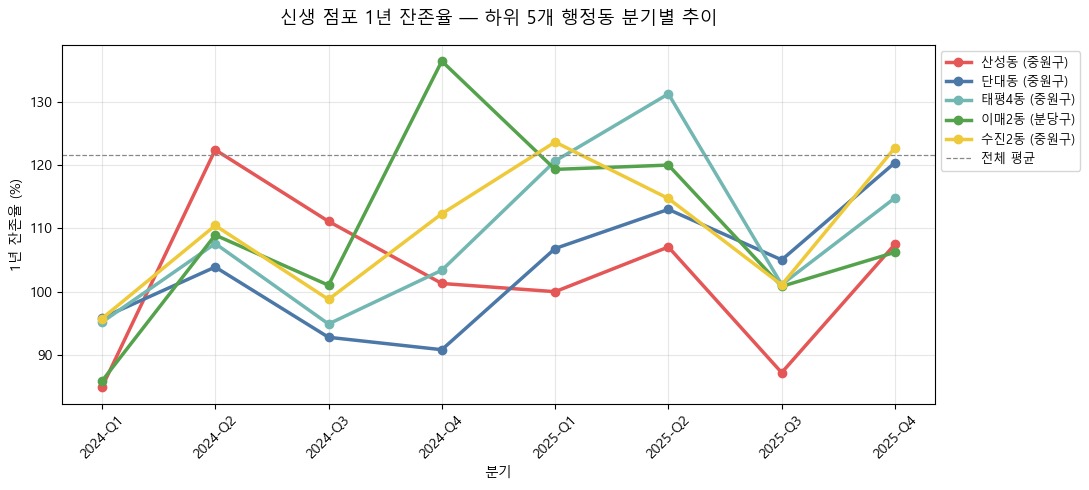

In [65]:
# ── 하위 5개 행정동 분기별 잔존율 라인 차트 ──────────────────────────
worst5 = pivot_surv.dropna(subset=["평균잔존율"]).head(5).index.get_level_values("행정동명").tolist()

fig, ax = plt.subplots(figsize=(11, 5))

# 1. 행정동별로 뚜렷하게 구분되는 5가지 색상 직접 지정
distinct_colors = ["#E45756", "#4C78A8", "#72B7B2", "#54A24B", "#EECA3B"]

for i, name in enumerate(worst5):
    grp = q_agg[q_agg["행정동명"] == name].dropna(subset=["잔존율"]).sort_values("_q_key")
    if grp.empty:
        continue
    
    gu = grp["구명"].iloc[0]
    
    # 2. gu_color 대신 distinct_colors의 인덱스를 사용하여 색상 할당
    ax.plot(
        grp["분기"].astype(str), grp["잔존율"],
        marker="o", linewidth=2.5,  # 시인성을 위해 선 굵기 살짝 상향
        color=distinct_colors[i], 
        label=f"{name} ({gu})",
    )

ax.axhline(pivot_surv["평균잔존율"].mean(), color="#888", linestyle="--",
           linewidth=0.9, label="전체 평균")

ax.set_title("신생 점포 1년 잔존율 — 하위 5개 행정동 분기별 추이", fontsize=13, pad=15)
ax.set_ylabel("1년 잔존율 (%)")
ax.set_xlabel("분기")
ax.tick_params(axis="x", rotation=45)

# 3. 범례 위치를 우측 바깥으로 옮겨 데이터와 겹치지 않게 설정
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 신생 점포 잔존율 기반 젠트리피케이션 단계 분류

**축**: 평균 1년 잔존율(수준) × 분기 기울기(추세)

| 단계 | 수준 | 추세 | 의미 |
|---|---|---|---|
| 초기 | 높음 | 상승 | 정상 시장 회전 |
| 주의 | 높음 | 하락 | 임대료 상승 압력 누적 |
| 경계 | 낮음 | 상승 | 회복 진행 |
| 위험 | 낮음 | 완만 하락 | 소상공인 진입 한계 도달 |
| 쇠퇴 | 낮음 | 급락 | 자본 교체 진행 |

- 위험 사분면(잔존율↓ 기울기↓) 내부를 기울기 중앙값으로 추가 분리 → **위험 / 쇠퇴**

In [66]:
# ── 분기별 잔존율 기울기 계산 + 5단계 분류 ───────────────────────────
from scipy import stats

def _slope(g):
    g = g.dropna(subset=["잔존율"]).sort_values("_q_key")
    if len(g) < 3:
        return np.nan
    return stats.linregress(np.arange(len(g)), g["잔존율"].values).slope

slope_q = (
    q_agg.groupby("행정동명").apply(_slope)
    .reset_index(name="기울기")
)

surv_q_stage = (
    q_agg.groupby(["행정동명", "구명"], as_index=False)
    .agg(평균잔존율=("잔존율", "mean"))
    .merge(slope_q, on="행정동명")
    .dropna(subset=["평균잔존율", "기울기"])
    .reset_index(drop=True)
)

# 중앙값 기준 사분면 + 위험/쇠퇴 분리
lvl_med = surv_q_stage["평균잔존율"].median()
slp_med = surv_q_stage["기울기"].median()

def _stage(row):
    high_lvl = row["평균잔존율"] >= lvl_med
    pos_slp  = row["기울기"]    >= 0
    if high_lvl and pos_slp:        return "초기"
    if high_lvl and not pos_slp:    return "주의"
    if not high_lvl and pos_slp:    return "경계"
    return "쇠퇴" if row["기울기"] < slp_med else "위험"

surv_q_stage["단계"] = surv_q_stage.apply(_stage, axis=1)
stage_order = ["초기", "주의", "경계", "위험", "쇠퇴"]

print("[ 단계별 행정동 수 ]")
print(surv_q_stage["단계"].value_counts().reindex(stage_order).fillna(0).astype(int).to_string())

print("\n[ 원도심 위험·경계·쇠퇴 단계 ]")
mask = (surv_q_stage["구명"].isin(["수정구", "중원구"]) &
        surv_q_stage["단계"].isin(["경계", "위험", "쇠퇴"]))
print(surv_q_stage.loc[mask, ["행정동명", "구명", "평균잔존율", "기울기", "단계"]]
      .round(2).sort_values(["단계", "평균잔존율"]).to_string(index=False))

[ 단계별 행정동 수 ]
단계
초기    24
주의     1
경계    24
위험     0
쇠퇴     1

[ 원도심 위험·경계·쇠퇴 단계 ]
 행정동명  구명  평균잔존율   기울기 단계
  단대동 중원구 103.57  3.03 경계
 태평4동 중원구 108.61  2.75 경계
 수진2동 중원구 109.94  2.40 경계
  복정동 중원구 112.21  3.83 경계
  시흥동 중원구 113.71  3.72 경계
 하대원동 수정구 115.65  4.37 경계
 금광1동 수정구 116.25  3.07 경계
  성남동 수정구 116.36  3.77 경계
 태평3동 중원구 118.16  3.73 경계
 신흥2동 중원구 118.35  1.46 경계
상대원1동 수정구 118.52  4.42 경계
상대원3동 수정구 119.11  6.20 경계
 수진1동 중원구 120.11  2.68 경계
 태평2동 중원구 121.04  4.24 경계
  산성동 중원구 102.69 -0.37 쇠퇴


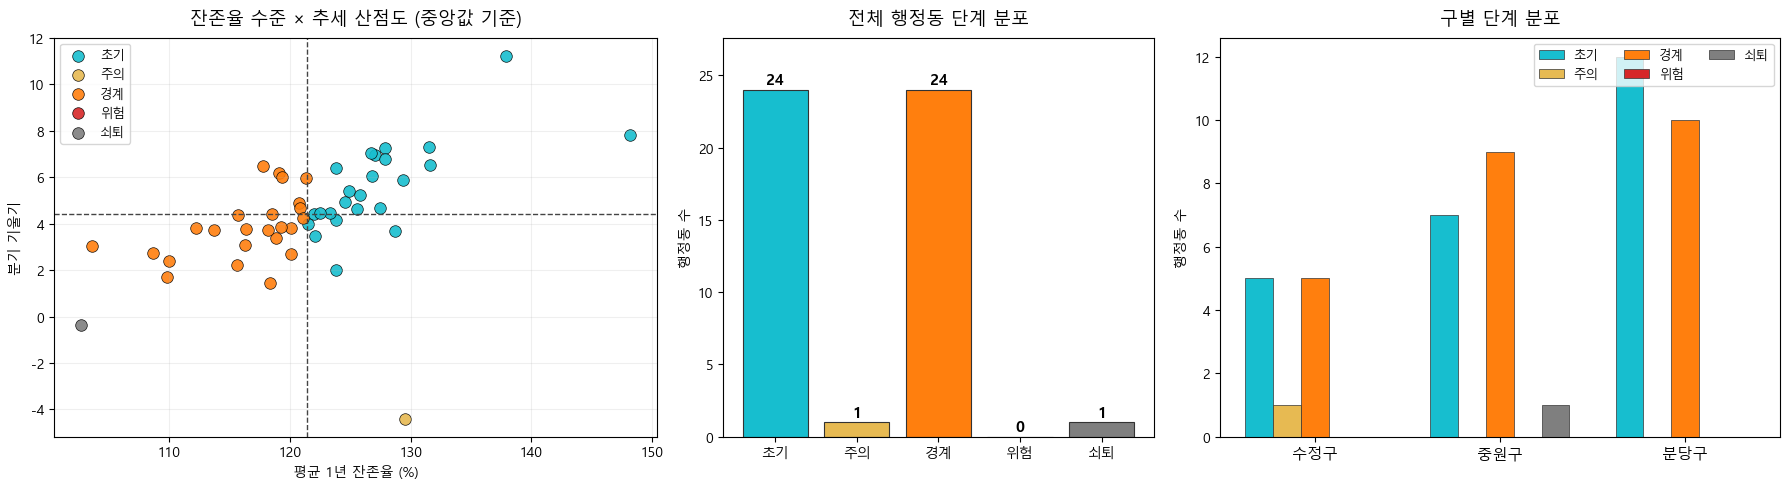

In [67]:
# ── 시각화: 산점도 + 전체 분포 + 구별 분포  ────────────────────────────
# 초기(청록), 주의(노랑), 경계(주황), 위험(빨강), 쇠퇴(보라/회색조)
stage_color = {
    "초기": "#17BECF",  # 밝은 청록
    "주의": "#E7BA52",  # 진한 황금색
    "경계": "#FF7F0E",  # 선명한 주황
    "위험": "#D62728",  # 강렬한 빨강
    "쇠퇴": "#7F7F7F"   # 차분한 회색 (위험과 대비)
}

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.4, 1, 1.3])

# (1) 산점도 ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for s in stage_order:
    grp = surv_q_stage[surv_q_stage["단계"] == s]
    ax.scatter(grp["평균잔존율"], grp["기울기"],
               color=stage_color[s], label=s,
               s=70, alpha=0.9, edgecolor="black", linewidth=0.5) # 테두리를 검정으로 하여 구분감 강화

ax.axhline(slp_med, color="#444", linestyle="--", linewidth=1)
ax.axvline(lvl_med, color="#444", linestyle="--", linewidth=1)
ax.set_xlabel("평균 1년 잔존율 (%)", fontsize=10)
ax.set_ylabel("분기 기울기", fontsize=10)
ax.set_title("잔존율 수준 × 추세 산점도 (중앙값 기준)", fontsize=13, pad=10)
ax.legend(fontsize=9, frameon=True); ax.grid(alpha=0.2)

# (2) 전체 단계 분포 ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
counts_total = [int(surv_q_stage["단계"].value_counts().get(s, 0)) for s in stage_order]
bars = ax.bar(stage_order, counts_total,
               color=[stage_color[s] for s in stage_order], edgecolor="#333", linewidth=0.8)

# 상단 숫자 표시 개선
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("전체 행정동 단계 분포", fontsize=13, pad=10)
ax.set_ylabel("행정동 수")
ax.set_ylim(0, max(counts_total) * 1.15) # 숫자 표시를 위해 y축 여유 공간 확보

# (3) 구별 분포 ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ct = (pd.crosstab(surv_q_stage["구명"], surv_q_stage["단계"])
      .reindex(columns=stage_order, fill_value=0)
      .reindex(["수정구", "중원구", "분당구"]))

x = np.arange(len(ct.index))
w = 0.15 # 바 너비 살짝 조절
for i, s in enumerate(stage_order):
    ax.bar(x + (i - 2) * w, ct[s].values, width=w,
           color=stage_color[s], label=s, edgecolor="#333", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=11)
ax.set_title("구별 단계 분포", fontsize=13, pad=10)
ax.set_ylabel("행정동 수")
# 범례를 그래프 하단이나 상단으로 깔끔하게 배치
ax.legend(fontsize=9, ncol=3, loc='upper right') 

plt.tight_layout()
plt.show()

# 그래프 해석

- 초기와 경계 단계가 동일한 비중으로 가장 많음. 이는 성남시 내 상권들이 안정적으로 자리를 잡아가고 있는 지역과, 생존율이 낮아지거나 하락 추세에 있어 집중 관리가 필요한 지역으로 양극화되어 있음을 시사함.
- 특히 '경계' 단계의 비중이 매우 높다는 점은 향후 상권 쇠퇴로 이어질 위험 요소가 다분함을 의미.
- 하위 5개 행정동의 분기별 추이를 보면, 전체 평균선 아래에서 등락 폭이 매우 큰 불안정한 모습을 보임.
- 이는 해당 지역 상권이 외부 환경 요인에 매우 취약하며, 자생적인 생존력을 확보하지 못한 것을 의미할 수 있음

## 핵심 지표별 분기 추이 — 상위/하위 5개 행정동

각 지표의 위험 신호가 가장 두드러지는 행정동(개업률·폐업률·프랜차이즈 침투율은 **상위 5**, 업종 다양성·잔존율은 **하위 5**)의 분기별 추이를 비교합니다.


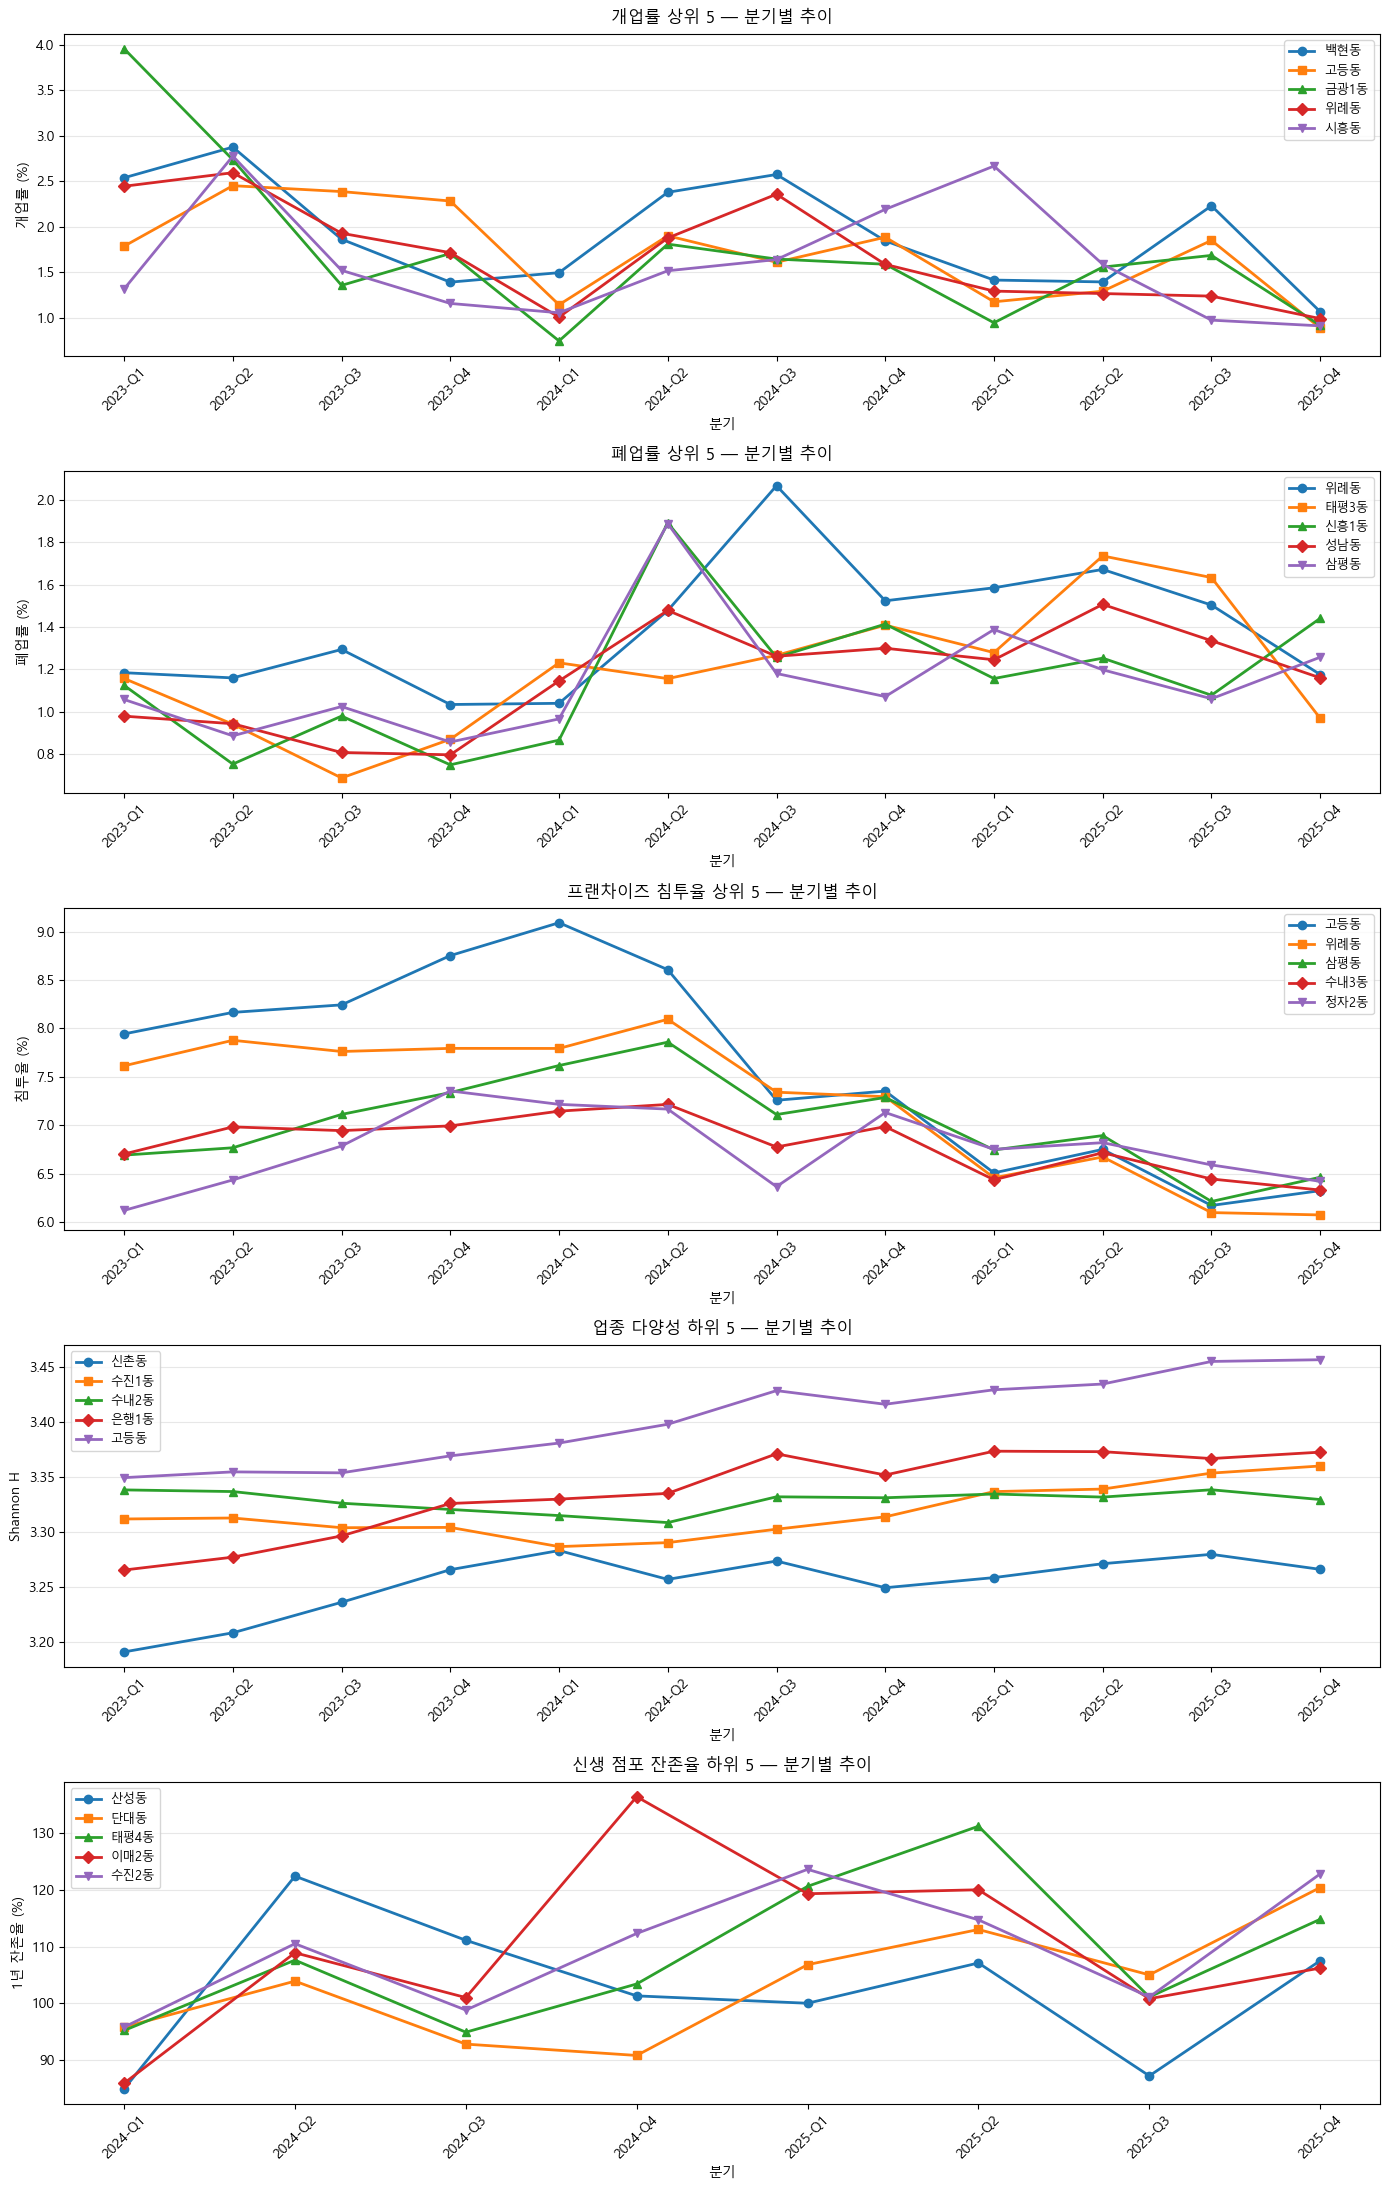

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# ── 분기별 데이터 재구성 (자기완결) ──────────────────────────────
df_eda["분기"] = df_eda["year"].astype(str) + "-Q" + df_eda["quarter"].astype(str)
quarter_order = sorted(df_eda["분기"].unique())

# 1) 개·폐업률 분기별
oc_q = (
    df_eda.groupby(["행정동명", "분기"])[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum().reset_index()
)
oc_q["개업률"] = oc_q["open_cnt"] / oc_q["mer_cnt"] * 100
oc_q["폐업률"] = oc_q["close_cnt"] / oc_q["mer_cnt"] * 100

top_open  = oc_q.groupby("행정동명")["개업률"].mean().nlargest(5).index.tolist()
top_close = oc_q.groupby("행정동명")["폐업률"].mean().nlargest(5).index.tolist()

# 2) 프랜차이즈 침투율 (pivot_q 재활용 가능하지만 안전하게 재계산)
fran_q = (
    df_eda.groupby(["행정동명", "분기"])[["fran_cnt", "mer_cnt"]]
    .sum().reset_index()
)
fran_q["침투율"] = fran_q["fran_cnt"] / fran_q["mer_cnt"] * 100
top_fran = fran_q.groupby("행정동명")["침투율"].mean().nlargest(5).index.tolist()

# 3) 업종 다양성 (div_h 사용)
top_div_low = div_h.groupby("행정동명")["다양성지수"].mean().nsmallest(5).index.tolist()

# 4) 잔존율 (pivot_surv 사용)
top_surv_low = (
    pivot_surv.dropna(subset=["평균잔존율"])
    .head(5).index.get_level_values("행정동명").tolist()
)

charts = [
    ("개업률 상위 5 — 분기별 추이",        oc_q,    "개업률",     top_open,     "개업률 (%)"),
    ("폐업률 상위 5 — 분기별 추이",        oc_q,    "폐업률",     top_close,    "폐업률 (%)"),
    ("프랜차이즈 침투율 상위 5 — 분기별 추이", fran_q,  "침투율",     top_fran,     "침투율 (%)"),
    ("업종 다양성 하위 5 — 분기별 추이",    div_h,   "다양성지수", top_div_low,  "Shannon H"),
    ("신생 점포 잔존율 하위 5 — 분기별 추이", None,   "잔존율",     top_surv_low, "1년 잔존율 (%)"),
]

fig, axes = plt.subplots(5, 1, figsize=(14, 22))
markers = ["o", "s", "^", "D", "v"]

for ax, (title, src, ycol, names, ylabel) in zip(axes, charts):
    if ycol == "잔존율":
        # pivot_surv를 long으로 변환
        ps = pivot_surv.drop(columns=["평균잔존율"], errors="ignore")
        for i, name in enumerate(names):
            row = ps[ps.index.get_level_values("행정동명") == name]
            if row.empty: continue
            ys = row.iloc[0]
            xs = [str(c) for c in ys.index]
            ax.plot(xs, ys.values, marker=markers[i], linewidth=2, markersize=6, label=name)
    else:
        for i, name in enumerate(names):
            grp = src[src["행정동명"] == name].sort_values("분기")
            ax.plot(grp["분기"].astype(str), grp[ycol],
                    marker=markers[i], linewidth=2, markersize=6, label=name)
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel("분기")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.show()


---

# 종합 해석

In [69]:
# ── 4개 지표 단계 통합 → 행정동별 종합 단계 산출 ─────────────────────
from scipy.stats import linregress  # noqa

stage_to_score = {"초기": 0, "주의": 1, "경계": 2, "위험": 3, "쇠퇴": 4}
score_to_stage = {v: k for k, v in stage_to_score.items()}
stage_order_all = ["초기", "주의", "경계", "위험", "쇠퇴"]

# ── 개폐업률 단계 재구성 (위 셀에서 사용한 로직과 동일) ─────────────
_dong = (
    df_eda.groupby(["행정동명", "구명"])[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
_dong["개업률"] = _dong["open_cnt"] / _dong["mer_cnt"] * 100
_dong["폐업률"] = _dong["close_cnt"] / _dong["mer_cnt"] * 100
_dong["순증감"] = _dong["개업률"] - _dong["폐업률"]
_med_o, _med_c = _dong["개업률"].median(), _dong["폐업률"].median()
def _classify_open(row):
    hi_o, hi_c = row["개업률"] >= _med_o, row["폐업률"] >= _med_c
    if hi_o and not hi_c: return "초기"
    if hi_o and hi_c:     return "주의" if row["순증감"] > 0 else "경계"
    if not hi_o and hi_c: return "위험"
    return "쇠퇴"
_dong["개폐업률_단계"] = _dong.apply(_classify_open, axis=1)

# ── 4개 지표 단계 추출 ────────────────────────────────────────────
df_open = _dong[["행정동명", "구명", "개폐업률_단계"]]
df_fran = fran_q_stage[["행정동명", "구명", "단계"]].rename(columns={"단계": "프랜차이즈_단계"})
df_div  = div_summary[["행정동명", "구명", "단계"]].rename(columns={"단계": "업종다양성_단계"})
df_surv = surv_q_stage[["행정동명", "구명", "단계"]].rename(columns={"단계": "잔존율_단계"})

# ── outer merge ────────────────────────────────────────────────
final_stage = (
    df_open
    .merge(df_fran, on=["행정동명", "구명"], how="outer")
    .merge(df_div,  on=["행정동명", "구명"], how="outer")
    .merge(df_surv, on=["행정동명", "구명"], how="outer")
)

# ── 단계 → 점수 → 종합 단계 ─────────────────────────────────────
stage_cols = ["개폐업률_단계", "프랜차이즈_단계", "업종다양성_단계", "잔존율_단계"]
score_cols = [c.replace("_단계", "_점수") for c in stage_cols]
for sc, pc in zip(stage_cols, score_cols):
    final_stage[pc] = final_stage[sc].map(stage_to_score)

final_stage["종합점수"] = final_stage[score_cols].mean(axis=1).round(2)
final_stage["종합단계"] = (
    final_stage[score_cols].mean(axis=1).round().astype("Int64").map(score_to_stage)
)

final_stage = final_stage.sort_values(
    ["종합점수", "구명", "행정동명"], ascending=[False, True, True]
).reset_index(drop=True)

display_cols = [
    "행정동명", "구명",
    "개폐업률_단계", "프랜차이즈_단계", "업종다양성_단계", "잔존율_단계",
    "종합점수", "종합단계",
]

print("=== 행정동별 4개 지표 단계 + 종합 단계 ===")
print(final_stage[display_cols].to_string(index=False))

print("=== 종합 단계별 행정동 수 (전체) ===")
print(final_stage["종합단계"].value_counts().reindex(stage_order_all, fill_value=0).to_string())

print("=== 원도심(수정구+중원구) 위험·쇠퇴 단계 행정동 ===")
원도심_risk = final_stage[
    (final_stage["구명"].isin(["수정구", "중원구"]))
    & (final_stage["종합단계"].isin(["위험", "쇠퇴"]))
]
print(원도심_risk[display_cols].to_string(index=False))


=== 행정동별 4개 지표 단계 + 종합 단계 ===
 행정동명  구명 개폐업률_단계 프랜차이즈_단계 업종다양성_단계 잔존율_단계  종합점수 종합단계
상대원1동 수정구      쇠퇴       주의       위험     경계  2.50   경계
  산성동 중원구      쇠퇴       경계       초기     쇠퇴  2.50   경계
 수내1동 분당구      주의       쇠퇴       경계     경계  2.25   경계
 정자3동 분당구      쇠퇴       쇠퇴       주의     초기  2.25   경계
  시흥동 중원구      주의       경계       쇠퇴     경계  2.25   경계
 신흥1동 중원구      경계       위험       쇠퇴     초기  2.25   경계
  양지동 중원구      위험       위험       위험     초기  2.25   경계
 태평1동 중원구      쇠퇴       쇠퇴       주의     초기  2.25   경계
  백현동 분당구      초기       위험       위험     경계  2.00   경계
  삼평동 분당구      주의       위험       경계     경계  2.00   경계
 서현1동 분당구      주의       위험       경계     경계  2.00   경계
 정자1동 분당구      주의       위험       경계     경계  2.00   경계
상대원2동 수정구      위험       주의       쇠퇴     초기  2.00   경계
 하대원동 수정구      쇠퇴       주의       주의     경계  2.00   경계
  단대동 중원구      쇠퇴       주의       주의     경계  2.00   경계
 수진2동 중원구      쇠퇴       초기       경계     경계  2.00   경계
 태평4동 중원구      쇠퇴       주의       주의     경계  2.00   경

## 종합 지표 기반 행정동 젠트리피케이션 단계 분포

4개 지표(개폐업률 / 프랜차이즈 침투율 / 업종 다양성 / 신생 점포 잔존율) 단계를 점수화(초기 0 → 쇠퇴 4)해 평균낸 **종합점수**와 그에 따른 **종합단계** 분포를 시각화합니다.


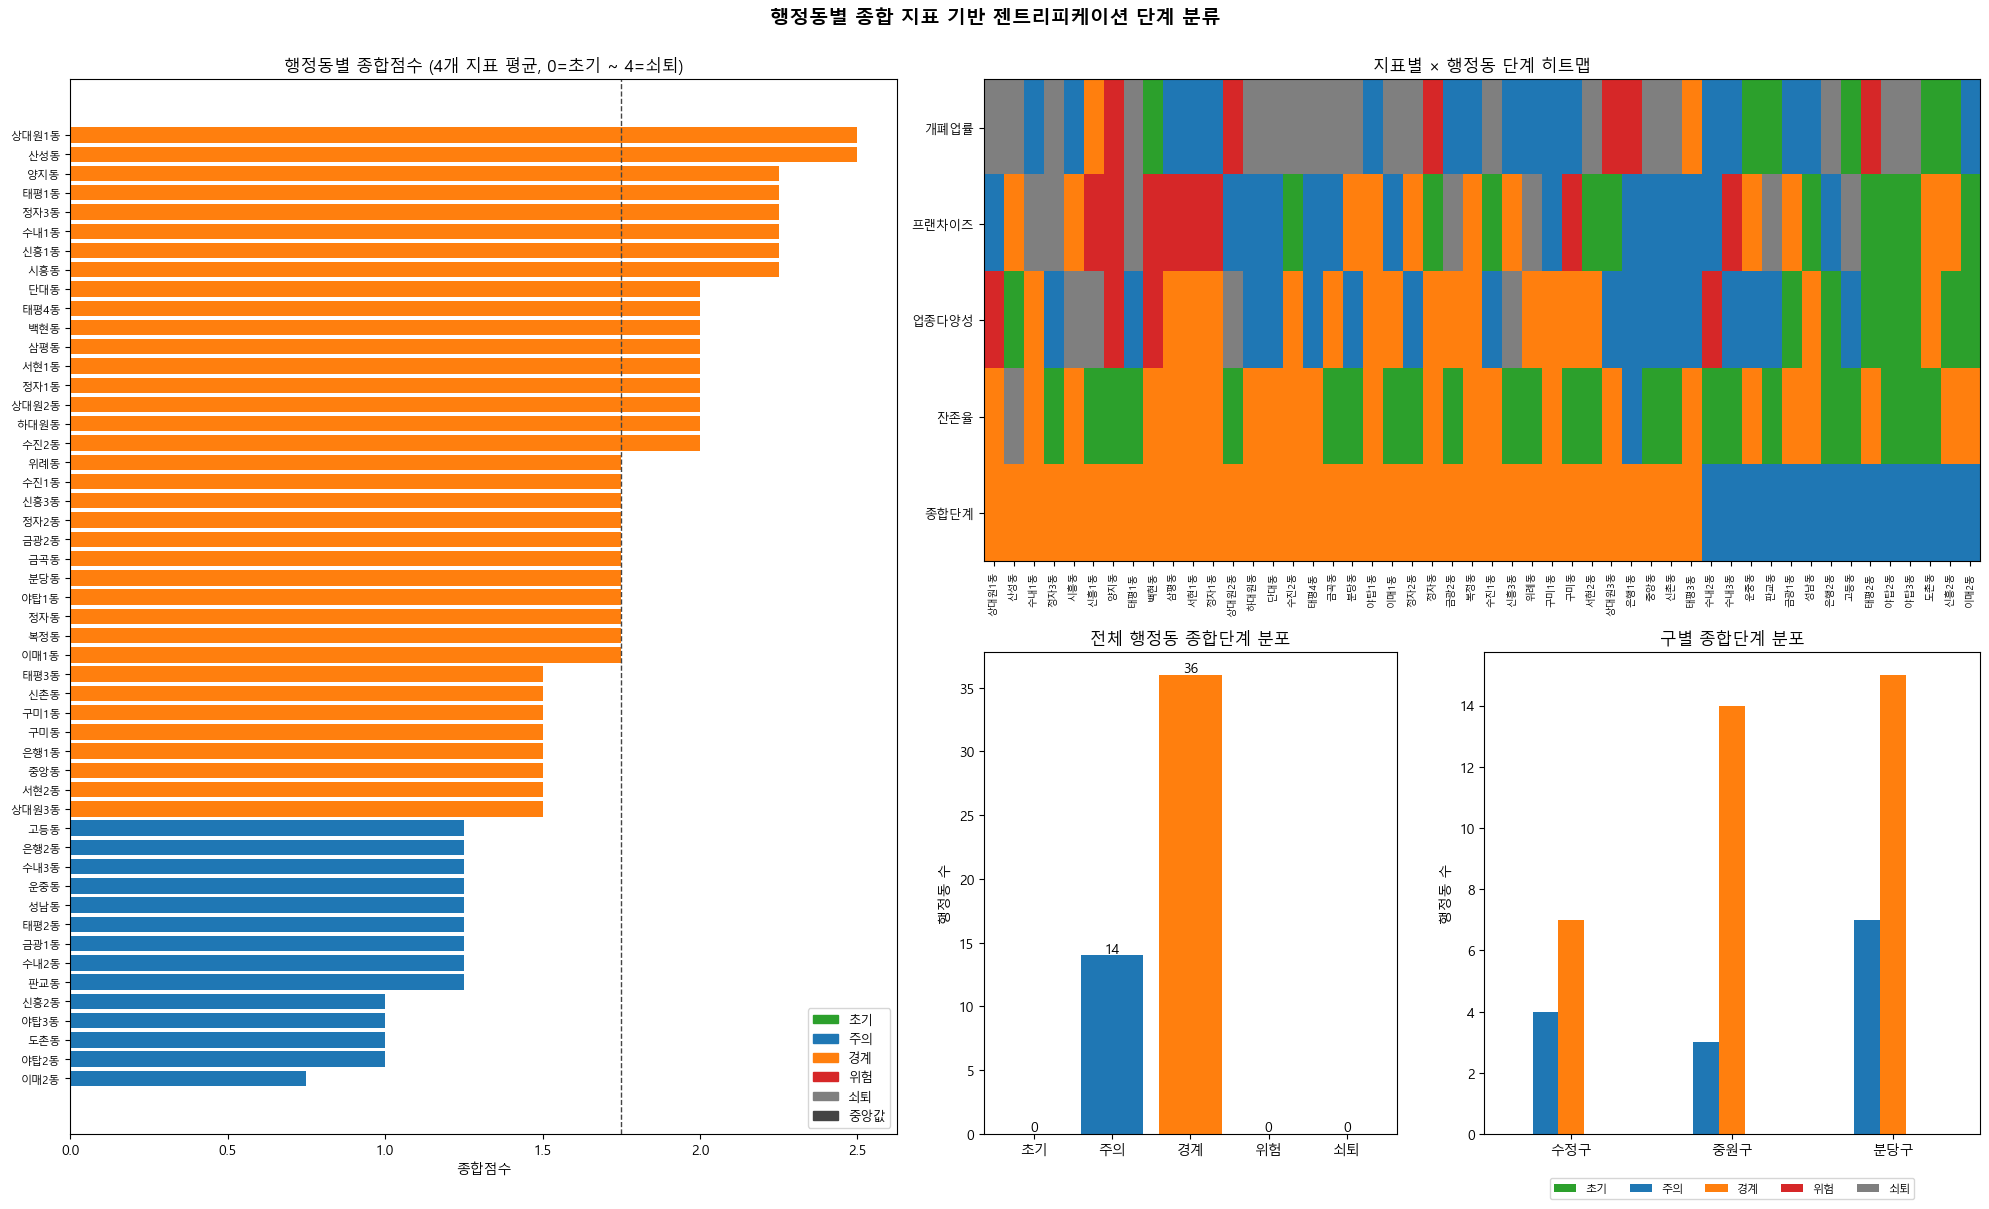

In [70]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np

stage_colors = {
    "초기": "#2ca02c",
    "주의": "#1f77b4",
    "경계": "#ff7f0e",
    "위험": "#d62728",
    "쇠퇴": "#7f7f7f",
}
stage_order_all = ["초기", "주의", "경계", "위험", "쇠퇴"]

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, width_ratios=[2.0, 1.0, 1.2], height_ratios=[1, 1])

# ── ① 좌측: 행정동별 종합점수 가로 막대 (종합단계 색상) ─────────
ax_bar = fig.add_subplot(gs[:, 0])
sorted_df = final_stage.sort_values("종합점수", ascending=True)
bar_colors = sorted_df["종합단계"].map(stage_colors).fillna("#cccccc")
ax_bar.barh(sorted_df["행정동명"], sorted_df["종합점수"], color=bar_colors.values)
ax_bar.set_title("행정동별 종합점수 (4개 지표 평균, 0=초기 ~ 4=쇠퇴)", fontsize=12)
ax_bar.set_xlabel("종합점수")
ax_bar.axvline(final_stage["종합점수"].median(), color="#444", linestyle="--", linewidth=1, label="중앙값")
legend_patches = [Patch(color=c, label=s) for s, c in stage_colors.items()]
ax_bar.legend(handles=legend_patches + [Patch(color="#444", label="중앙값")],
              fontsize=9, loc="lower right")
ax_bar.tick_params(axis="y", labelsize=8)

# ── ② 우상단: 지표 × 행정동 단계 히트맵 ──────────────────────────
ax_hm = fig.add_subplot(gs[0, 1:])
stage_cols_hm = ["개폐업률_단계", "프랜차이즈_단계", "업종다양성_단계", "잔존율_단계", "종합단계"]
hm_df = final_stage.set_index("행정동명")[stage_cols_hm]
score_to_int = {"초기": 0, "주의": 1, "경계": 2, "위험": 3, "쇠퇴": 4}
hm_data = hm_df.apply(lambda col: col.map(lambda v: score_to_int.get(v, np.nan))).values
cmap = ListedColormap([stage_colors[s] for s in stage_order_all])
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)
ax_hm.imshow(hm_data.T, aspect="auto", cmap=cmap, norm=norm)
ax_hm.set_yticks(range(len(stage_cols_hm)))
ax_hm.set_yticklabels([c.replace("_단계", "") for c in stage_cols_hm], fontsize=9)
ax_hm.set_xticks(range(len(hm_df)))
ax_hm.set_xticklabels(hm_df.index, rotation=90, fontsize=7)
ax_hm.set_title("지표별 × 행정동 단계 히트맵", fontsize=12)

# ── ③ 우하단-좌: 전체 종합단계 분포 ─────────────────────────────
ax_tot = fig.add_subplot(gs[1, 1])
counts_total = [int(final_stage["종합단계"].value_counts().get(s, 0)) for s in stage_order_all]
ax_tot.bar(stage_order_all, counts_total, color=[stage_colors[s] for s in stage_order_all])
for x, v in enumerate(counts_total):
    ax_tot.text(x, v + 0.2, str(v), ha="center", fontsize=10)
ax_tot.set_title("전체 행정동 종합단계 분포", fontsize=12)
ax_tot.set_ylabel("행정동 수")

# ── ④ 우하단-우: 구별 종합단계 분포 ─────────────────────────────
ax_gu = fig.add_subplot(gs[1, 2])
gus = ["수정구", "중원구", "분당구"]
x = np.arange(len(gus))
width = 0.16
for i, s in enumerate(stage_order_all):
    counts = [
        final_stage[(final_stage["구명"] == g) & (final_stage["종합단계"] == s)].shape[0]
        for g in gus
    ]
    ax_gu.bar(x + (i - 2) * width, counts, width, label=s, color=stage_colors[s])
ax_gu.set_xticks(x)
ax_gu.set_xticklabels(gus)
ax_gu.set_title("구별 종합단계 분포", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))

plt.suptitle("행정동별 종합 지표 기반 젠트리피케이션 단계 분류",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()
